# Plot and Filter Contaminants Across Data Sets

- want to loop over different sample types within project
- From merged, project specific dataset files
- Export and Save Files
- collapseNoMismatch processed data (Dada2 program)

### Imports

In [1]:
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt
import glob


#For illustrator import:
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

### File Locations

In [2]:
prefix = 'AVITI_MiSeq_comparson_subsetted'

#Data Directory
directory = '../data/AVITI_subsetted/Dada2_seq_data/'

#Directory for saving Figures
plot_dir = '../figures/AVITI_subsetted/'
print(plot_dir)

../figures/AVITI_subsetted/


### Functions

In [3]:
# Dada2 Banzai Output Functions
levels = ['Kingdom', 'Phylum', 'Class', 'Order', 'Family', 'Genus', 'Species']

def make_metadata(infile):
    df = pd.read_csv(infile)
    df.set_index('sample_name', inplace=True)
    return df

#Raw Read Numbers
def make_taxa_otu_tables(infile):
    #infile = ASV_taxa_table_all.csv
    df = pd.read_csv(infile, sep=',')
    df.set_index('ASV', inplace=True)
    otu_table = df.drop(levels, axis=1)
    taxa_table = df[levels]
    return otu_table, taxa_table

#From fasta file create pandas df of ASV and sequence
def from_fasta_to_df(file):
    print(file)
    with open(file) as f:
        Ids=[]
        seqs =[]
        for strline in f:
            if strline[0]=='>':
                Ids.append(strline[1:].strip())
            else:
                seqs.append(strline.strip())
    print('Number of Ids:',len(Ids))
    print('Number of Seqs:',len(seqs))
    seq_dict = dict(zip(Ids, seqs))
    #make pandas df
    df= pd.DataFrame.from_dict(seq_dict,orient='index', columns=['sequence'])
    return df

#from metadata file, limit OTU table and taxa table to those present in those samples
def from_metadata_to_taxareads(meta_data, otu_table, taxa_table):
    #standard M6 output; sample_names as index; OTUs as index
    cols = list(meta_data)
    otu_lim = pd.concat([meta_data, otu_table.T],join='inner', axis=1)
    otu_lim.drop(cols, inplace=True, axis=1)
    otu_lim=otu_lim.T
    otu_lim['Total']=otu_lim.sum(axis=1)
    otu_lim = otu_lim.loc[otu_lim['Total']>0]
    otu_lim.drop('Total', axis=1, inplace=True)
    cols=list(otu_lim)
    taxa_lim=pd.concat([otu_lim, taxa_table], axis=1, join='inner')
    taxa_lim.drop(cols, inplace=True, axis=1)
    return otu_lim, taxa_lim

def from_taxa_to_otutab(taxa_table, otu_table):
    #remove OTUs not in the taxa table
    otu_lim = pd.concat([taxa_table, otu_table],join='inner', axis=1)
    otu_lim.drop(levels, inplace=True, axis=1)
    return otu_lim

#Plot number of reads in controls
#By Species
def OTUs_in_controls_plot(otu_tab, taxa_tab, meta_data):
    from palettable.tableau import Tableau_20 as pr
    cmap=pr.mpl_colormap
    #define control samples by non-environmental samples
    df=meta_data.copy()
    grouped = ['Kingdom', 'Phylum', 'Class', 'Order']
    #grouped= ['Kingdom', 'Phylum', 'Class', 'Order', 'Family', 'Genus', 'Species']
    df = df.loc[df['sample_type']!='environmental']
    df = df.loc[df['sample_type']!='positive']
    controls = df.index.tolist()
    print('controls:', controls)
    df=df.sort_index()
    df=df[['library','sample_type', 'target_gene']]
    #Now look at reads in controls
    df= pd.concat([df, otu_tab.T], axis=1,join='inner')
    df.index.name = 'sample_name'
    df=df.reset_index().set_index(['sample_name', 'library','sample_type','target_gene'])
    df=df.T
    df['Tot'] = df.sum(axis=1)
    df=df.loc[df['Tot']>0]
    col_name = list(df)[-1]
    print(col_name)
    df.drop(col_name, axis=1, inplace=True)
    df=pd.concat([df, taxa_tab], axis=1, join='inner')
    df=df.groupby(levels).sum()
    df['Tot'] = df.sum(axis=1)
    df=df.groupby(grouped).sum()
    df=df.sort_values('Tot', ascending=False)
    df=df.head(n=20)
    col_name = list(df)[-1]
    print(col_name)
    df.drop(col_name, axis=1, inplace=True)
    df=df.T
    df = df.sort_index()
    df.plot(kind='barh',stacked=True, cmap=cmap, figsize=[8,8])
    plt.legend(bbox_to_anchor=(1.04, 1), loc=2, borderaxespad=0.,ncol=1, fontsize='12')
    plt.title('Top 20 Control ASV Taxonomy by Raw Read Abundance', y=1.03, fontsize='14')
    plt.xlabel('Number of Raw Reads')
    filename=plot_dir +'Control_plot_'+marker+'.pdf'
    print(filename)
    plt.savefig(filename,dpi=None, facecolor='w', edgecolor='w',
            orientation='landscape', papertype=None, format=None,
            transparent=True, bbox_inches='tight', pad_inches=1,
            frameon=None)
    plt.show()
    

# 18S - MiSeq Data - 115 trunc length

## Load Data

In [4]:
marker = '18S'

print('#####' +marker + '#####')

# otu table
file = prefix + '_'+marker+'_Dada2_asv_merged.csv'
print(directory+file)
df = pd.read_csv(directory + file)
df = df.rename(columns= {'Unnamed: 0':'ASV'})
df.set_index('ASV', inplace=True)
otu_all = df.copy()
print('Number ASVs:', len(df.index))

# taxa table
file = prefix + '_'+marker+'_Dada2_taxa_merged.csv'
print(directory+file)
df = pd.read_csv(directory+file)
df = df.rename(columns= {'Unnamed: 0':'ASV'})
df.set_index('ASV', inplace=True)
taxa_all = df.copy()
print('Number ASVs:', len(df.index))

# metadata
file = prefix + '_'+marker+'_Dada2_meta_merged.csv'
print(directory+file)
df = pd.read_csv(directory+file)
df.set_index('sample_name', inplace=True)
df['eventDate'] = pd.to_datetime(df['eventDate'])
meta_all = df.copy()
print('Number samples:', len(df.index))

# sequence table
file = prefix + '_'+marker+'_Dada2_seq_merged.csv'
print(directory+file)
df = pd.read_csv(directory +file)
df = df.rename(columns= {'Unnamed: 0':'ASV'})
df.set_index('ASV', inplace=True)
seq_all = df.copy()
print('Number ASVs:', len(df.index))
seq_all.head()

#####18S#####
../data/AVITI_subsetted/Dada2_seq_data/AVITI_MiSeq_comparson_subsetted_18S_Dada2_asv_merged.csv
Number ASVs: 7282
../data/AVITI_subsetted/Dada2_seq_data/AVITI_MiSeq_comparson_subsetted_18S_Dada2_taxa_merged.csv
Number ASVs: 7282
../data/AVITI_subsetted/Dada2_seq_data/AVITI_MiSeq_comparson_subsetted_18S_Dada2_meta_merged.csv
Number samples: 190
../data/AVITI_subsetted/Dada2_seq_data/AVITI_MiSeq_comparson_subsetted_18S_Dada2_seq_merged.csv
Number ASVs: 7282


,sequence
ASV,
ASV_1,GCTACTACCGATTGAACGTTTTAGTGAGGTATTTGGACTGGGCCTT...
ASV_2,GCTCCTACCGATTGAGTGATCCGGTGAATAATTCGGACTGCAGCAG...
ASV_3,GCTACTACCGATTGAACGTTTTAGTGAGGTCCACGGACTGTTTGCA...
ASV_4,GCTACTACCGATTGAACATTTTAGTGAGGTCCTCGGACTGTGAGCC...
ASV_5,GCACCTACCGATTGAATGGTCCGGTGAAGCCTCGGGATTGTGGTTA...


In [5]:
#check what samples don't have date/time values
df = meta_all.copy()
df = df.sort_values('eventDate')
#df.loc[df['date'].isna(), 'eventDate'] = df['SAMPLING_date_time']
df=df.loc[df['eventDate'].isna()]
print('Samples without date:')
print(df.index.unique())
df

Samples without date:
Index(['CN24F150mMV2_SC42_FD', 'CN24F150mMV2_SC43_FD', 'CN24F150mMV2_SC44_FD',
       'CN24F150mMV2_SC45_FD', 'CN24F150mMV2_SC46_FD', 'CN24F150mMV2_SC47_FD',
       'CN24F150mMV2_SC48_FD', 'CN24F150mMV2_SC49_FD', 'CN24F150mMV2_SC50_FD',
       'CN24F150mMV2_SC51_FD', 'CN24F150mMV2_SC52_FD', 'CN24F150mMV2_SC53_FD',
       'CN24F150mMV2_SC54_FD', 'CN24F150mMV2_SC55_FD', 'CN24F150mMV2_SC56_FD',
       'CN24F150mMV2_SC57_FD', 'CN24F150mMV2_SC58_FD', 'CN24F150mMV2_SC59_FD',
       'subsampled_CN24F150mMV2_SC42_FKsubsampled',
       'subsampled_CN24F150mMV2_SC43_FKsubsampled',
       'subsampled_CN24F150mMV2_SC44_FKsubsampled',
       'subsampled_CN24F150mMV2_SC45_FKsubsampled',
       'subsampled_CN24F150mMV2_SC46_FKsubsampled',
       'subsampled_CN24F150mMV2_SC47_FKsubsampled',
       'subsampled_CN24F150mMV2_SC48_FKsubsampled',
       'subsampled_CN24F150mMV2_SC49_FKsubsampled',
       'subsampled_CN24F150mMV2_SC50_FKsubsampled',
       'subsampled_CN24F150mMV2_SC51

,ESP,PlateID,R1,R2,SAMPLING_PI,SAMPLING_bottle,SAMPLING_cruise,SAMPLING_institute,SAMPLING_platform,SAMPLING_platform_type,...,sample_type,seqID,seq_meth,sequencing_facility,tag_sequence,target_gene,temp,year,month,day
sample_name,,,,,,,,,,,,,,,,,,,,,
CN24F150mMV2_SC42_FD,NaN,FD,CN24F150mMV2_SC42_S72_L001_R1_001.fastq.gz,CN24F150mMV2_SC42_S72_L001_R2_001.fastq.gz,Francisco Chavez,NaN,NaN,MBARI,NaN,NaN,...,environmental,CN24F150mMV2_SC42_FD,NGS Illumina Miseq,MSU,CGGTAGAGTT,18S,NaN,NaN,NaN,NaN
CN24F150mMV2_SC43_FD,NaN,FD,CN24F150mMV2_SC43_S73_L001_R1_001.fastq.gz,CN24F150mMV2_SC43_S73_L001_R2_001.fastq.gz,Francisco Chavez,NaN,NaN,MBARI,NaN,NaN,...,environmental,CN24F150mMV2_SC43_FD,NGS Illumina Miseq,MSU,CGTGACTCTA,18S,NaN,NaN,NaN,NaN
CN24F150mMV2_SC44_FD,NaN,FD,CN24F150mMV2_SC44_S74_L001_R1_001.fastq.gz,CN24F150mMV2_SC44_S74_L001_R2_001.fastq.gz,Francisco Chavez,NaN,NaN,MBARI,NaN,NaN,...,environmental,CN24F150mMV2_SC44_FD,NGS Illumina Miseq,MSU,CTTCAATAGC,18S,NaN,NaN,NaN,NaN
CN24F150mMV2_SC45_FD,NaN,FD,CN24F150mMV2_SC45_S75_L001_R1_001.fastq.gz,CN24F150mMV2_SC45_S75_L001_R2_001.fastq.gz,Francisco Chavez,NaN,NaN,MBARI,NaN,NaN,...,environmental,CN24F150mMV2_SC45_FD,NGS Illumina Miseq,MSU,AAGGACTCAG,18S,NaN,NaN,NaN,NaN
CN24F150mMV2_SC46_FD,NaN,FD,CN24F150mMV2_SC46_S76_L001_R1_001.fastq.gz,CN24F150mMV2_SC46_S76_L001_R2_001.fastq.gz,Francisco Chavez,NaN,NaN,MBARI,NaN,NaN,...,environmental,CN24F150mMV2_SC46_FD,NGS Illumina Miseq,MSU,CAGACGATGA,18S,NaN,NaN,NaN,NaN
CN24F150mMV2_SC47_FD,NaN,FD,CN24F150mMV2_SC47_S77_L001_R1_001.fastq.gz,CN24F150mMV2_SC47_S77_L001_R2_001.fastq.gz,Francisco Chavez,NaN,NaN,MBARI,NaN,NaN,...,environmental,CN24F150mMV2_SC47_FD,NGS Illumina Miseq,MSU,TTGGAAGTAC,18S,NaN,NaN,NaN,NaN
CN24F150mMV2_SC48_FD,NaN,FD,CN24F150mMV2_SC48_S78_L001_R1_001.fastq.gz,CN24F150mMV2_SC48_S78_L001_R2_001.fastq.gz,Francisco Chavez,NaN,NaN,MBARI,NaN,NaN,...,environmental,CN24F150mMV2_SC48_FD,NGS Illumina Miseq,MSU,TCGCATCAAC,18S,NaN,NaN,NaN,NaN
CN24F150mMV2_SC49_FD,NaN,FD,CN24F150mMV2_SC49_S79_L001_R1_001.fastq.gz,CN24F150mMV2_SC49_S79_L001_R2_001.fastq.gz,Francisco Chavez,NaN,NaN,MBARI,NaN,NaN,...,environmental,CN24F150mMV2_SC49_FD,NGS Illumina Miseq,MSU,TATGCAACTC,18S,NaN,NaN,NaN,NaN
CN24F150mMV2_SC50_FD,NaN,FD,CN24F150mMV2_SC50_S80_L001_R1_001.fastq.gz,CN24F150mMV2_SC50_S80_L001_R2_001.fastq.gz,Francisco Chavez,NaN,NaN,MBARI,NaN,NaN,...,environmental,CN24F150mMV2_SC50_FD,NGS Illumina Miseq,MSU,GAATGTCACG,18S,NaN,NaN,NaN,NaN


In [6]:
df = meta_all.copy()
print(list(df))
# Filter blanks

df = df.loc[df['sample_type'] == 'environmental']
# df = df[['PlateID', 'sample_type', 'target_gene', 'PCR_settings', 'eventDate', 'SAMPLING_cruise', 'depth', 'decimalLatitude', 'decimalLongitude', 'seqID']]

#bucket samples = 0m depth


df = df.loc[df['depth'].isna() == True]
df = df.dropna(how='all', axis=1)
df

['ESP', 'PlateID', 'R1', 'R2', 'SAMPLING_PI', 'SAMPLING_bottle', 'SAMPLING_cruise', 'SAMPLING_institute', 'SAMPLING_platform', 'SAMPLING_platform_type', 'SAMPLING_rdepth', 'SAMPLING_station', 'SAMPLING_station_number', 'SC', 'chlorophyll', 'decimalLatitude', 'decimalLongitude', 'density', 'depth', 'diss_oxygen', 'env_broad_scale', 'env_local_scale', 'env_medium', 'eventDate', 'fluor', 'geo_loc_name', 'library', 'nitrate', 'order', 'original_name', 'pressure', 'primer_sequence_forward', 'primer_sequence_reverse', 'project_name', 'replicate', 'salinity', 'samp_filter_ext_type', 'samp_filter_size_ext', 'samp_store_temp', 'sample_type', 'seqID', 'seq_meth', 'sequencing_facility', 'tag_sequence', 'target_gene', 'temp', 'year', 'month', 'day']


,ESP,PlateID,R1,R2,SAMPLING_PI,SAMPLING_institute,SAMPLING_platform_type,SC,env_broad_scale,env_local_scale,...,primer_sequence_reverse,samp_filter_ext_type,samp_filter_size_ext,samp_store_temp,sample_type,seqID,seq_meth,sequencing_facility,tag_sequence,target_gene
sample_name,,,,,,,,,,,,,,,,,,,,,
CN24F150mMV2_SC42_FD,NaN,FD,CN24F150mMV2_SC42_S72_L001_R1_001.fastq.gz,CN24F150mMV2_SC42_S72_L001_R2_001.fastq.gz,Francisco Chavez,MBARI,NaN,NaN,marine biome (ENVO:00000447),coastal water (ENVO:00001250),...,TGATCCTTCTGCAGGTTCACCTAC,Poretics,0.22um,-80,environmental,CN24F150mMV2_SC42_FD,NGS Illumina Miseq,MSU,CGGTAGAGTT,18S
CN24F150mMV2_SC43_FD,NaN,FD,CN24F150mMV2_SC43_S73_L001_R1_001.fastq.gz,CN24F150mMV2_SC43_S73_L001_R2_001.fastq.gz,Francisco Chavez,MBARI,NaN,NaN,marine biome (ENVO:00000447),coastal water (ENVO:00001250),...,TGATCCTTCTGCAGGTTCACCTAC,Poretics,0.22um,-80,environmental,CN24F150mMV2_SC43_FD,NGS Illumina Miseq,MSU,CGTGACTCTA,18S
CN24F150mMV2_SC44_FD,NaN,FD,CN24F150mMV2_SC44_S74_L001_R1_001.fastq.gz,CN24F150mMV2_SC44_S74_L001_R2_001.fastq.gz,Francisco Chavez,MBARI,NaN,NaN,marine biome (ENVO:00000447),coastal water (ENVO:00001250),...,TGATCCTTCTGCAGGTTCACCTAC,Poretics,0.22um,-80,environmental,CN24F150mMV2_SC44_FD,NGS Illumina Miseq,MSU,CTTCAATAGC,18S
CN24F150mMV2_SC45_FD,NaN,FD,CN24F150mMV2_SC45_S75_L001_R1_001.fastq.gz,CN24F150mMV2_SC45_S75_L001_R2_001.fastq.gz,Francisco Chavez,MBARI,NaN,NaN,marine biome (ENVO:00000447),coastal water (ENVO:00001250),...,TGATCCTTCTGCAGGTTCACCTAC,Poretics,0.22um,-80,environmental,CN24F150mMV2_SC45_FD,NGS Illumina Miseq,MSU,AAGGACTCAG,18S
CN24F150mMV2_SC46_FD,NaN,FD,CN24F150mMV2_SC46_S76_L001_R1_001.fastq.gz,CN24F150mMV2_SC46_S76_L001_R2_001.fastq.gz,Francisco Chavez,MBARI,NaN,NaN,marine biome (ENVO:00000447),coastal water (ENVO:00001250),...,TGATCCTTCTGCAGGTTCACCTAC,Poretics,0.22um,-80,environmental,CN24F150mMV2_SC46_FD,NGS Illumina Miseq,MSU,CAGACGATGA,18S
CN24F150mMV2_SC47_FD,NaN,FD,CN24F150mMV2_SC47_S77_L001_R1_001.fastq.gz,CN24F150mMV2_SC47_S77_L001_R2_001.fastq.gz,Francisco Chavez,MBARI,NaN,NaN,marine biome (ENVO:00000447),coastal water (ENVO:00001250),...,TGATCCTTCTGCAGGTTCACCTAC,Poretics,0.22um,-80,environmental,CN24F150mMV2_SC47_FD,NGS Illumina Miseq,MSU,TTGGAAGTAC,18S
CN24F150mMV2_SC48_FD,NaN,FD,CN24F150mMV2_SC48_S78_L001_R1_001.fastq.gz,CN24F150mMV2_SC48_S78_L001_R2_001.fastq.gz,Francisco Chavez,MBARI,NaN,NaN,marine biome (ENVO:00000447),coastal water (ENVO:00001250),...,TGATCCTTCTGCAGGTTCACCTAC,Poretics,0.22um,-80,environmental,CN24F150mMV2_SC48_FD,NGS Illumina Miseq,MSU,TCGCATCAAC,18S
CN24F150mMV2_SC49_FD,NaN,FD,CN24F150mMV2_SC49_S79_L001_R1_001.fastq.gz,CN24F150mMV2_SC49_S79_L001_R2_001.fastq.gz,Francisco Chavez,MBARI,NaN,NaN,marine biome (ENVO:00000447),coastal water (ENVO:00001250),...,TGATCCTTCTGCAGGTTCACCTAC,Poretics,0.22um,-80,environmental,CN24F150mMV2_SC49_FD,NGS Illumina Miseq,MSU,TATGCAACTC,18S
CN24F150mMV2_SC50_FD,NaN,FD,CN24F150mMV2_SC50_S80_L001_R1_001.fastq.gz,CN24F150mMV2_SC50_S80_L001_R2_001.fastq.gz,Francisco Chavez,MBARI,NaN,NaN,marine biome (ENVO:00000447),coastal water (ENVO:00001250),...,TGATCCTTCTGCAGGTTCACCTAC,Poretics,0.22um,-80,environmental,CN24F150mMV2_SC50_FD,NGS Illumina Miseq,MSU,GAATGTCACG,18S


In [7]:
# # look at netfilt
# df = meta_all.copy()
# print(list(df))
# # Filter blanks
# #df = df.loc[df.index.str.contains('FB')]
# df.loc[df.index.str.contains('FB'), 'sample_type'] = 'negative'
# df.loc[df.index.str.contains('_ND_'), 'sample_type'] = 'netdrip'
# df = df.loc[df['sample_type']=='netdrip']

# from palettable.tableau import Tableau_20 as pr
# cmap=pr.mpl_colormap

# #grouped = ['Kingdom', 'Phylum', 'Class', 'Order']
# grouped= ['Kingdom', 'Phylum', 'Class', 'Order', 'Family', 'Genus', 'Species']
# #df = df.loc[df['sample_type']!='environmental']
# print(df['sample_type'].unique())
# #df = df.loc[df['sample_type']=='positive']
# print(list(df))
# controls = df.index.tolist()
# print('controls:', controls)
# df=df.sort_index()
# df=df[['library','sample_type', 'target_gene']]
# #Now look at reads in controls
# df= pd.concat([df, otu_all.T], axis=1,join='inner')
# df.index.name = 'sample_name'
# df=df.reset_index().set_index(['sample_name', 'library','sample_type','target_gene'])
# df=df.T
# df['Tot'] = df.sum(axis=1)
# df=df.loc[df['Tot']>0]
# col_name = list(df)[-1]
# print(col_name)
# df.drop(col_name, axis=1, inplace=True)
# df=pd.concat([df, taxa_all], axis=1, join='inner')
# df=df.groupby(levels).sum()
# df['Tot'] = df.sum(axis=1)
# df=df.groupby(grouped).sum()
# df=df.sort_values('Tot', ascending=False)
# df=df.head(n=20)
# col_name = list(df)[-1]
# print(col_name)
# df.drop(col_name, axis=1, inplace=True)
# df = df.sort_index()
# df=df.T
# df = df.sort_index()
# df.plot(kind='barh',stacked=True, cmap=cmap, figsize=[10,8])
# plt.legend(bbox_to_anchor=(1.04, 1), loc=2, borderaxespad=0.,ncol=1, fontsize='12')
# plt.title('Top 20 Control ASV Taxonomy by Raw Read Abundance', y=1.03, fontsize='14')
# plt.xlabel('Number of Raw Reads')

# df


## Analyze Control Samples

### Plot Positive Controls

['negative' 'positive']
['ESP', 'PlateID', 'R1', 'R2', 'SAMPLING_PI', 'SAMPLING_bottle', 'SAMPLING_cruise', 'SAMPLING_institute', 'SAMPLING_platform', 'SAMPLING_platform_type', 'SAMPLING_rdepth', 'SAMPLING_station', 'SAMPLING_station_number', 'SC', 'chlorophyll', 'decimalLatitude', 'decimalLongitude', 'density', 'depth', 'diss_oxygen', 'env_broad_scale', 'env_local_scale', 'env_medium', 'eventDate', 'fluor', 'geo_loc_name', 'library', 'nitrate', 'order', 'original_name', 'pressure', 'primer_sequence_forward', 'primer_sequence_reverse', 'project_name', 'replicate', 'salinity', 'samp_filter_ext_type', 'samp_filter_size_ext', 'samp_store_temp', 'sample_type', 'seqID', 'seq_meth', 'sequencing_facility', 'tag_sequence', 'target_gene', 'temp', 'year', 'month', 'day']
controls: ['Art_Comm_FWAQ_FD', 'subsampled_Art_Comm_FWAQ_FKsubsampled']
('Tot', '', '', '')
Tot
../figures/AVITI_subsetted/PosControl_plot_18S.pdf


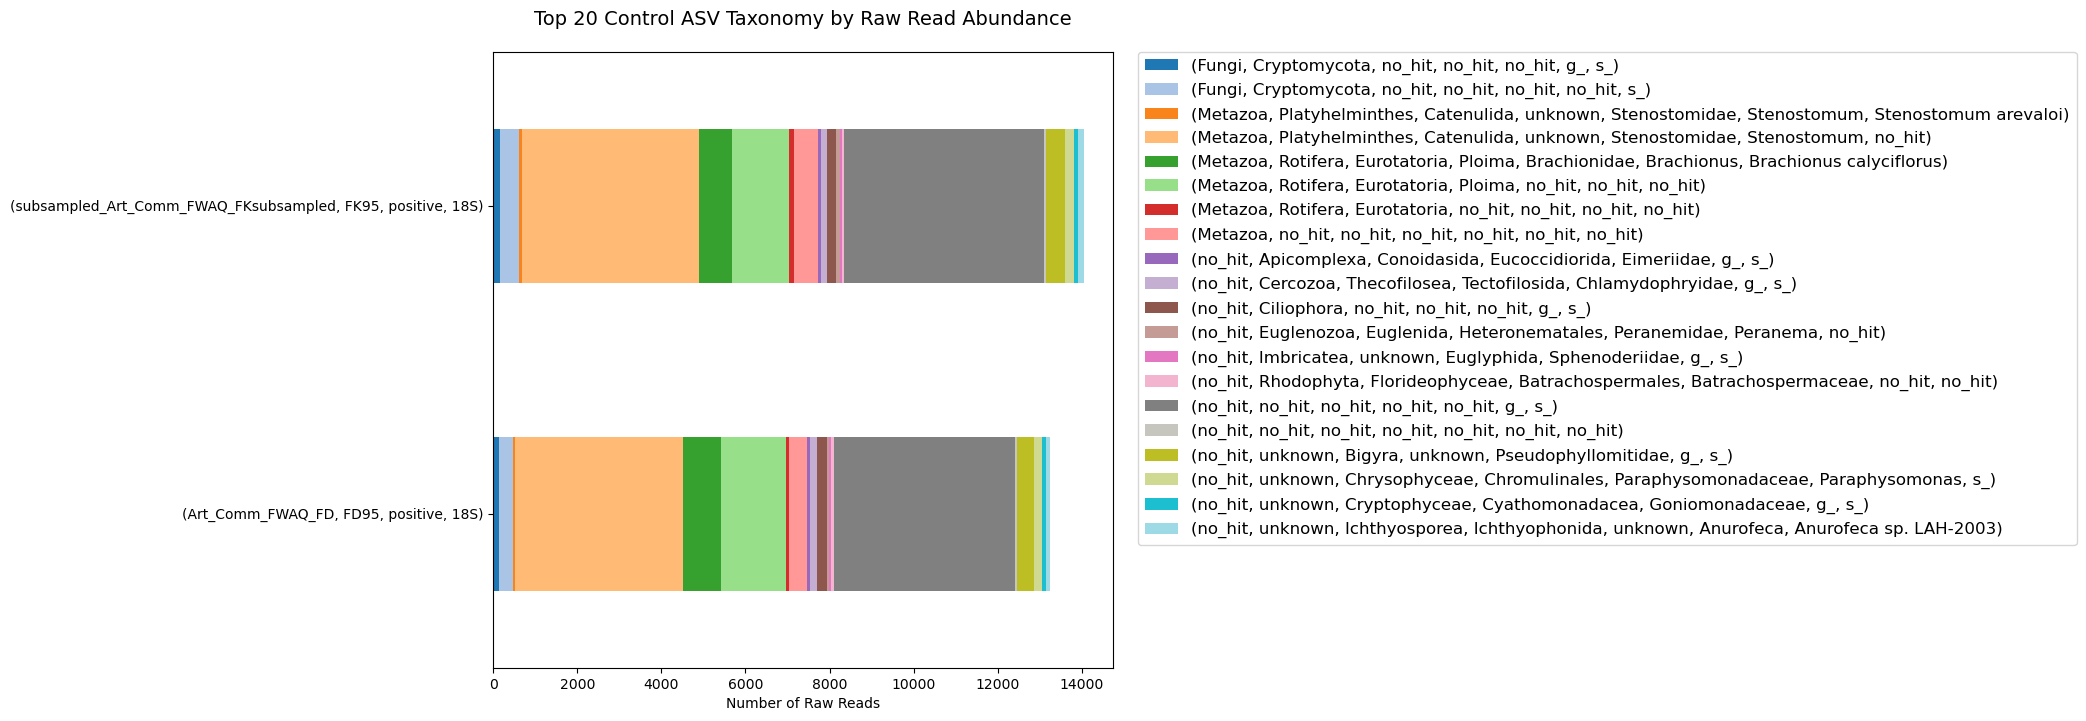

In [8]:
df = meta_all.copy()
df = df.loc[df['sample_type']!='environmental']

from palettable.tableau import Tableau_20 as pr
cmap=pr.mpl_colormap

#grouped = ['Kingdom', 'Phylum', 'Class', 'Order']
grouped= ['Kingdom', 'Phylum', 'Class', 'Order', 'Family', 'Genus', 'Species']
#df = df.loc[df['sample_type']!='environmental']
print(df['sample_type'].unique())
df = df.loc[df['sample_type']=='positive']
print(list(df))
controls = df.index.tolist()
print('controls:', controls)
df=df.sort_index()
df=df[['library','sample_type', 'target_gene']]
#Now look at reads in controls
df= pd.concat([df, otu_all.T], axis=1,join='inner')
df.index.name = 'sample_name'
df=df.reset_index().set_index(['sample_name', 'library','sample_type','target_gene'])
df=df.T
df['Tot'] = df.sum(axis=1)
df=df.loc[df['Tot']>0]
col_name = list(df)[-1]
print(col_name)
df.drop(col_name, axis=1, inplace=True)
df=pd.concat([df, taxa_all], axis=1, join='inner')
df=df.groupby(levels).sum()
df['Tot'] = df.sum(axis=1)
df=df.groupby(grouped).sum()
df=df.sort_values('Tot', ascending=False)
df=df.head(n=20)
col_name = list(df)[-1]
print(col_name)
df.drop(col_name, axis=1, inplace=True)
df = df.sort_index()
df=df.T
df = df.sort_index()
df.plot(kind='barh',stacked=True, cmap=cmap, figsize=[8,8])
plt.legend(bbox_to_anchor=(1.04, 1), loc=2, borderaxespad=0.,ncol=1, fontsize='12')
plt.title('Top 20 Control ASV Taxonomy by Raw Read Abundance', y=1.03, fontsize='14')
plt.xlabel('Number of Raw Reads')
filename=plot_dir +'PosControl_plot_'+marker+'.pdf'
print(filename)
plt.savefig(filename,dpi=None, facecolor='w', edgecolor='w',
        orientation='landscape', format=None,
        transparent=True, bbox_inches='tight', pad_inches=1)
plt.show()


### Plot Negative Controls

['negative' 'positive']
controls: ['CN24F150mMV2_preblank_FD', 'CN24F150mMV2_postblank_FD', 'CN_MBTS_Dual_extraction_P1_DNA_EB_FD', 'pcrblank1_FD', 'pcrblank2_FD', 'subsampled_CN24F150mMV2_preblank_FKsubsampled', 'subsampled_CN24F150mMV2_postblank_FKsubsampled', 'subsampled_CN_MBTS_Dual_extraction_P1_DNA_EB_FKsubsampled', 'subsampled_pcrblank1_FKsubsampled', 'subsampled_pcrblank2_FKsubsampled']
('Tot', '', '', '')
Tot
../figures/AVITI_subsetted/NegControl_plot_18S.pdf


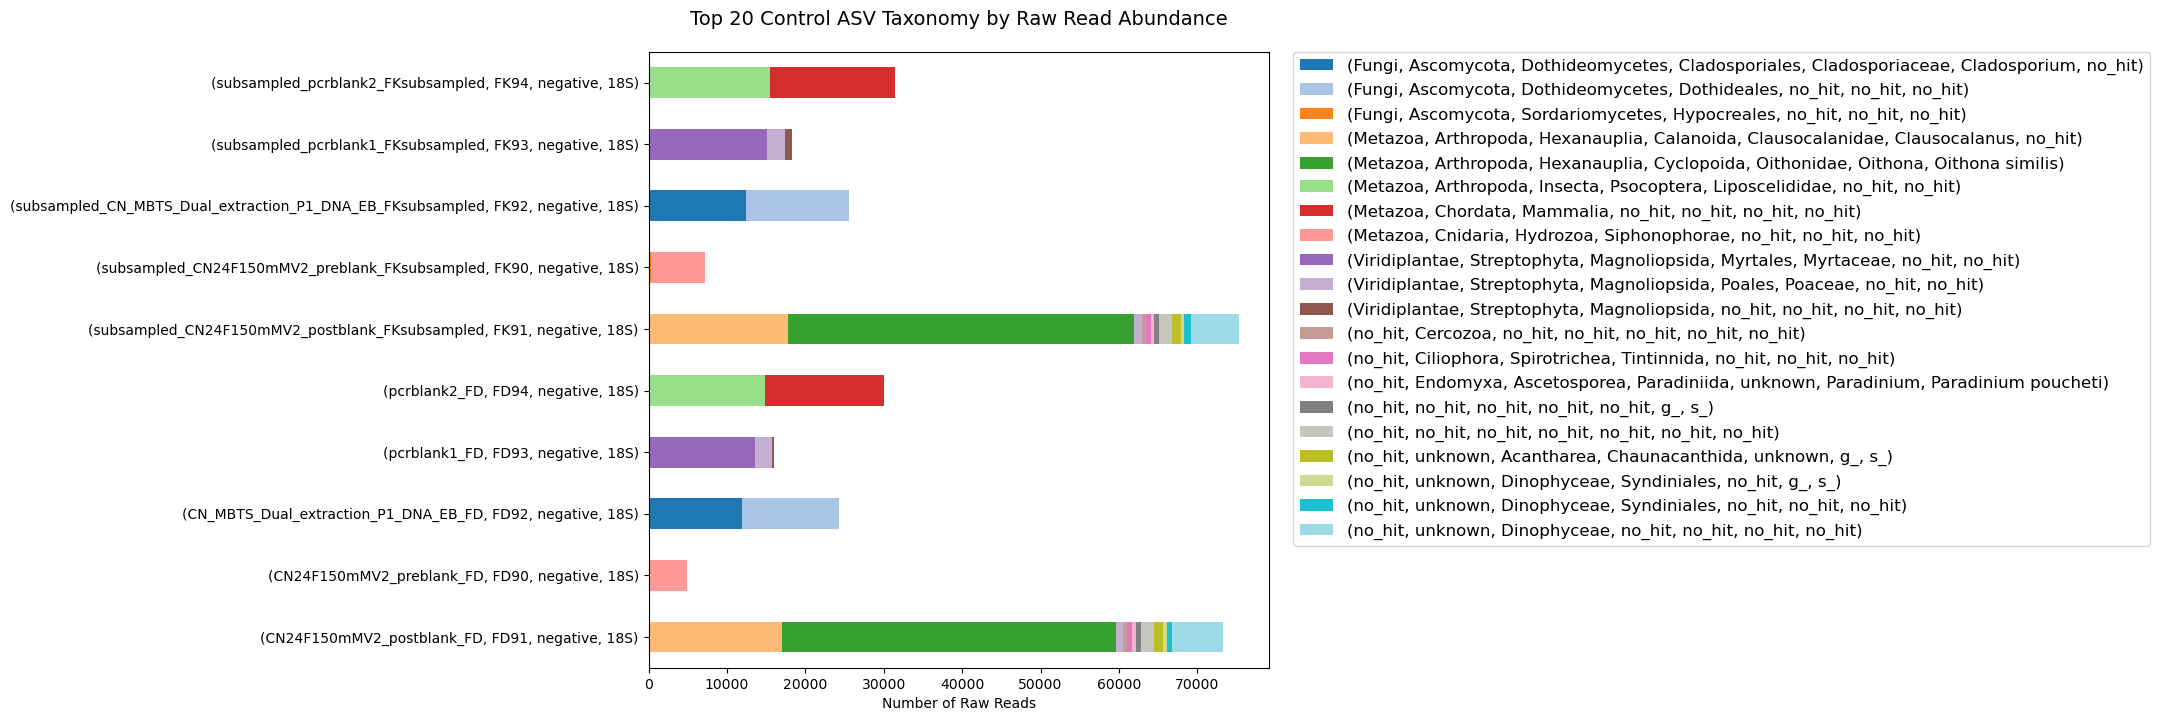

In [9]:
df = meta_all.copy()
df = df.loc[df['sample_type']!='environmental']

from palettable.tableau import Tableau_20 as pr
cmap=pr.mpl_colormap

#grouped = ['Kingdom', 'Phylum', 'Class', 'Order']
grouped= ['Kingdom', 'Phylum', 'Class', 'Order', 'Family', 'Genus', 'Species']
#df = df.loc[df['sample_type']!='environmental']
print(df['sample_type'].unique())
df = df.loc[df['sample_type']!='positive']
controls = df.index.tolist()
print('controls:', controls)
df=df.sort_index()
df=df[['library','sample_type', 'target_gene']]
#Now look at reads in controls
df= pd.concat([df, otu_all.T], axis=1,join='inner')
df.index.name = 'sample_name'
df=df.reset_index().set_index(['sample_name', 'library','sample_type','target_gene'])
df=df.T
df['Tot'] = df.sum(axis=1)
df=df.loc[df['Tot']>0]
col_name = list(df)[-1]
print(col_name)
df.drop(col_name, axis=1, inplace=True)
df=pd.concat([df, taxa_all], axis=1, join='inner')
df=df.groupby(levels).sum()
df['Tot'] = df.sum(axis=1)
df=df.groupby(grouped).sum()
df=df.sort_values('Tot', ascending=False)
df=df.head(n=20)
col_name = list(df)[-1]
print(col_name)
df.drop(col_name, axis=1, inplace=True)
df = df.sort_index()
df=df.T
df = df.sort_index()
df.plot(kind='barh',stacked=True, cmap=cmap, figsize=[8,8])
plt.legend(bbox_to_anchor=(1.04, 1), loc=2, borderaxespad=0.,ncol=1, fontsize='12')
plt.title('Top 20 Control ASV Taxonomy by Raw Read Abundance', y=1.03, fontsize='14')
plt.xlabel('Number of Raw Reads')
filename=plot_dir +'NegControl_plot_'+marker+'.pdf'
print(filename)
plt.savefig(filename,dpi=None, facecolor='w', edgecolor='w',
        orientation='landscape', format=None,
        transparent=True, bbox_inches='tight', pad_inches=1)
plt.show()


## Remove Control Samples

In [10]:
### Remove control samples
df = meta_all.copy()
df1 = df.loc[df['sample_type']!='environmental']
print('Samples removed as non-environmental:')
print(df1.index.unique())
df = df.loc[df['sample_type']=='environmental']
# df = df[['PlateID', 'sample_type', 'target_gene', 'replicate', 'eventDate', 'SAMPLING_cruise', 'SAMPLING_station_number', 'SAMPLING_bottle', 'SAMPLING_station', 'depth', 'sample_source', 'decimalLatitude', 'decimalLongitude', 'samp_filter_size_ext', 'filter_type', 'filter_style', 'seqID', 'tube_name']]


#print(df['SAMPLING_station'].unique())
#print(list(df))

meta_project = df.copy()
otu_project, taxa_project = from_metadata_to_taxareads(meta_project, otu_all, taxa_all)
meta_project.head()

Samples removed as non-environmental:
Index(['CN24F150mMV2_preblank_FD', 'CN24F150mMV2_postblank_FD',
       'CN_MBTS_Dual_extraction_P1_DNA_EB_FD', 'pcrblank1_FD', 'pcrblank2_FD',
       'Art_Comm_FWAQ_FD', 'subsampled_CN24F150mMV2_preblank_FKsubsampled',
       'subsampled_CN24F150mMV2_postblank_FKsubsampled',
       'subsampled_CN_MBTS_Dual_extraction_P1_DNA_EB_FKsubsampled',
       'subsampled_pcrblank1_FKsubsampled',
       'subsampled_pcrblank2_FKsubsampled',
       'subsampled_Art_Comm_FWAQ_FKsubsampled'],
      dtype='object', name='sample_name')


,ESP,PlateID,R1,R2,SAMPLING_PI,SAMPLING_bottle,SAMPLING_cruise,SAMPLING_institute,SAMPLING_platform,SAMPLING_platform_type,...,sample_type,seqID,seq_meth,sequencing_facility,tag_sequence,target_gene,temp,year,month,day
sample_name,,,,,,,,,,,,,,,,,,,,,
14223c01_05c_eDNA_FD,NaN,FD,14223c01_05c_eDNA_S1_L001_R1_001.fastq.gz,14223c01_05c_eDNA_S1_L001_R2_001.fastq.gz,Francisco Chavez,5.0,14223.0,MBARI,Rachel Carson,ship,...,environmental,14223c01_05c_eDNA_FD,NGS Illumina Miseq,MSU,GATTCACGAC,18S,7.8849,2023.0,5.0,22.0
14223c01_07c_eDNA_FD,NaN,FD,14223c01_07c_eDNA_S2_L001_R1_001.fastq.gz,14223c01_07c_eDNA_S2_L001_R2_001.fastq.gz,Francisco Chavez,7.0,14223.0,MBARI,Rachel Carson,ship,...,environmental,14223c01_07c_eDNA_FD,NGS Illumina Miseq,MSU,AGAACCTCGC,18S,8.4879,2023.0,5.0,22.0
14223c01_06c_eDNA_FD,NaN,FD,14223c01_06c_eDNA_S3_L001_R1_001.fastq.gz,14223c01_06c_eDNA_S3_L001_R2_001.fastq.gz,Francisco Chavez,6.0,14223.0,MBARI,Rachel Carson,ship,...,environmental,14223c01_06c_eDNA_FD,NGS Illumina Miseq,MSU,ATCCGATCTT,18S,8.3253,2023.0,5.0,22.0
14223c01_10c_eDNA_FD,NaN,FD,14223c01_10c_eDNA_S4_L001_R1_001.fastq.gz,14223c01_10c_eDNA_S4_L001_R2_001.fastq.gz,Francisco Chavez,10.0,14223.0,MBARI,Rachel Carson,ship,...,environmental,14223c01_10c_eDNA_FD,NGS Illumina Miseq,MSU,AGAGAGACCG,18S,12.6401,2023.0,5.0,22.0
14223c01_04c_eDNA_FD,NaN,FD,14223c01_04c_eDNA_S5_L001_R1_001.fastq.gz,14223c01_04c_eDNA_S5_L001_R2_001.fastq.gz,Francisco Chavez,4.0,14223.0,MBARI,Rachel Carson,ship,...,environmental,14223c01_04c_eDNA_FD,NGS Illumina Miseq,MSU,CTTGAAGAGG,18S,7.3874,2023.0,5.0,22.0


## Limit by Taxonomy and ASV length

In [11]:
df= taxa_project.copy()
df=df.loc[df['Kingdom'].isin(['Bacteria', 'Archaea'])==False]
df=df.loc[df['Phylum'].isin(['Proteobacteria'])==False]
df=df.loc[df['Order'].isin(['Siluriformes', 'Centrarchiformes'])==False]
df=df.loc[df['Species'].isin(['bacterium'])==False]
#for 12S limit to
if marker == '12S':
    df = df.loc[df['Phylum']=='Chordata']
df=df.loc[df['Class'].isin(['Insecta', 'Arachnida','Amphibia'])==False]
# for consistency, replace Artiodactyla with Cetacea, if marine mammals are being mislabeled in genbank
print(df.loc[df['Order']=='Artiodactyla'])
#df['Order'] = df['Order'].str.replace('Artiodactyla', 'Cetacea')
#remove terrestrial bird and mammal families:
fams = ['Hominidae','Canidae','Scincidae','Suidae', 'Bovidae', 'Felidae',
        'Phasianidae','Castoridae','Hirundinidae','Sittidae','Columbidae',
        'Falconidae','Leporidae','Muridae','Fringillidae','Mephitidae',
        'Rhinolophidae','Certhiidae', 'Characidae', 'Callichthyidae', 'Loricariidae', 'Poeciliidae']
df = df.loc[df['Family'].isin(fams)==False]

#fix some taxonomy classifications
df.loc[df['Family'].str.contains('Embiotocidae')==True, 'Order'] = 'Ovalentaria' # surfperches 
df.loc[df['Family'].str.contains('Sciaenidae')==True, 'Order'] = 'Eupercaria' # drums 
df.loc[df['Family'].str.contains('Moronidae')==True, 'Order'] = 'Eupercaria' # temprate basses
df.loc[df['Class'].str.contains('Dinophyceae')==True, 'Phylum'] = 'Dinophyceae' # dinoflagellates 

print(df['Order'].unique())

taxa_project_nocontam = df.copy()

#check sequence length
df = pd.concat([df,seq_all ], axis=1, join='inner')
seq_project_nocontam = df[['sequence']]
df['len'] = df['sequence'].str.len()
print('Mean sequence length:',df['len'].mean())
print('Median sequence length:',df['len'].median())
print('Min sequence length:',df['len'].min())
print('Max sequence length:',df['len'].max())
print('STD:',df['len'].std())
print(df['Phylum'].unique())
print('number of ASVs: ', len(df))

#from restricted taxa table limit otu table
otu_project_nocontam = from_taxa_to_otutab(taxa_project_nocontam, otu_project)
otu_project_nocontam.head()

Empty DataFrame
Columns: [Kingdom, Phylum, Class, Order, Family, Genus, Species]
Index: []
['Cyclopoida' 'no_hit' 'Calanoida' 'Bacillariales' 'Chaetocerotales'
 'Thalassiosirales' 'unknown' 'Copelata' 'Siphonophorae' 'Gonyaulacales'
 'Syndiniales' 'Gymnodiniales' 'Phaeocystales' 'Thaumatomonadida'
 'Diplonemea' 'Euphausiacea' 'unassigned' 'Nassellaria' 'Prorocentrales'
 'Myrtales' 'Semaeostomeae' 'Dothideales' 'Cladosporiales' 'Naviculales'
 'Halocyprida' 'Peridiniales' 'Coccidiniales' 'Poecilostomatoida'
 'Stephanodiscales' 'Pyrenomonadales' 'Suessiales' 'Terebellida'
 'Acanthoecida' 'Exobasidiales' 'Chaunacanthida' 'Rhizosoleniales'
 'Melosirales' 'Dinophysiales' 'Lagenidiales' 'Nanomonadea' 'Ploima'
 'Isochrysidales' 'Prorodontida' 'Coscinodiscales' 'Anthoathecata'
 'Collodaria' 'Craspedida' 'Tintinnida' 'Poales' 'Telonemida'
 'Mamiellales' 'Cymatosirales' 'Lithodesmiales' 'Spumellaria'
 'Oblongichytrida' 'Hemiaulales' 'Fragilariales' 'Thraustochytrida'
 'Trachymedusae' 'Eucoccidior

,14223c01_05c_eDNA_FD,14223c01_07c_eDNA_FD,14223c01_06c_eDNA_FD,14223c01_10c_eDNA_FD,14223c01_04c_eDNA_FD,14223c01_09c_eDNA_FD,14223c01_02c_eDNA_FD,14223c01_01c_eDNA_FD,14223c01_03c_eDNA_FD,14223c01_12c_eDNA_FD,...,subsampled_CN24F150mMV2_SC50_FKsubsampled,subsampled_CN24F150mMV2_SC51_FKsubsampled,subsampled_CN24F150mMV2_SC52_FKsubsampled,subsampled_CN24F150mMV2_SC53_FKsubsampled,subsampled_CN24F150mMV2_SC54_FKsubsampled,subsampled_CN24F150mMV2_SC55_FKsubsampled,subsampled_CN24F150mMV2_SC56_FKsubsampled,subsampled_CN24F150mMV2_SC57_FKsubsampled,subsampled_CN24F150mMV2_SC58_FKsubsampled,subsampled_CN24F150mMV2_SC59_FKsubsampled
ASV_1,4,11,9,16248,2,2954,6,2,4,7812,...,18591,9314,21977,23,10817,18,3806,24,9667,1837
ASV_2,1663,4489,3468,895,683,517,1084,682,598,732,...,5861,6928,3732,7177,5131,5796,7283,6188,5586,4588
ASV_3,248,2,2,3023,0,21307,0,0,0,0,...,2,9,3,24344,0,7,3,10970,12,7
ASV_4,0,0,0,6178,0,0,18,0,0,4135,...,4,7,3,1338,6,8,14,4,7,9
ASV_5,0,0,0,34,0,4,6,0,1,30,...,60,75,59,60,57,42,91,56,72,71


## Fix metadata

In [12]:
df = meta_project.copy()
print(list(df))

df.loc[df['original_name'].str.contains('BSMPA')==True, 'sample_source'] = 'MPA'
df.loc[df['original_name'].str.contains('MV1')==True, 'sample_source'] = 'ESP'

df.loc[df['original_name'].str.contains('CN24F150m')==True, 'depth'] = 150
df['depth_round'] = df['depth'].astype(float).round().astype(int) 


df.loc[df['original_name'].str.contains('14223')==True, 'sample_source'] = 'CN23S MARS'
df.loc[df['original_name'].str.contains('25424')==True, 'sample_source'] = 'MBTS 25424'
df.loc[df['original_name'].str.contains('22624')==True, 'sample_source'] = 'MBTS 22624'
df.loc[df['original_name'].str.contains('20524')==True, 'sample_source'] = 'MBTS 20524'
df.loc[df['original_name'].str.contains('17024')==True, 'sample_source'] = 'MBTS 17024'
df.loc[df['original_name'].str.contains('CN24F150m')==True, 'sample_source'] = 'CN24F 150m exp'

df.loc[df['seq_meth'].str.contains('NGS')==True, 'sequencer'] = 'MiSeq'
df.loc[df['seq_meth'].str.contains('AVITI')==True, 'sequencer'] = 'AVITI'

df['source_depth'] = df['sample_source'].str.cat(df['depth_round'].astype(str), sep=' ')

# df=df.loc[df['sample_source'] =='ESP'].df.loc[df.SC.isna()]
# print(df)
# print(df.SC.unique())

print(df)
# 'SAMPLING_dec_lat', 'SAMPLING_dec_lon', 'SAMPLING_dec_long','decimalLatitude', 'decimalLongitude'
# df.loc[df['decimalLatitude'].isna()==True, 'decimalLatitude'] = df['SAMPLING_dec_lat']
# df.loc[df['decimalLongitude'].isna()==True, 'decimalLongitude'] = df['SAMPLING_dec_long']
# df.loc[df['decimalLongitude'].isna()==True, 'decimalLongitude'] = df['SAMPLING_dec_lon']
meta_project = df.copy()
df.head()

['ESP', 'PlateID', 'R1', 'R2', 'SAMPLING_PI', 'SAMPLING_bottle', 'SAMPLING_cruise', 'SAMPLING_institute', 'SAMPLING_platform', 'SAMPLING_platform_type', 'SAMPLING_rdepth', 'SAMPLING_station', 'SAMPLING_station_number', 'SC', 'chlorophyll', 'decimalLatitude', 'decimalLongitude', 'density', 'depth', 'diss_oxygen', 'env_broad_scale', 'env_local_scale', 'env_medium', 'eventDate', 'fluor', 'geo_loc_name', 'library', 'nitrate', 'order', 'original_name', 'pressure', 'primer_sequence_forward', 'primer_sequence_reverse', 'project_name', 'replicate', 'salinity', 'samp_filter_ext_type', 'samp_filter_size_ext', 'samp_store_temp', 'sample_type', 'seqID', 'seq_meth', 'sequencing_facility', 'tag_sequence', 'target_gene', 'temp', 'year', 'month', 'day']
                                           ESP       PlateID  \
sample_name                                                    
14223c01_05c_eDNA_FD                       NaN            FD   
14223c01_07c_eDNA_FD                       NaN            FD

,ESP,PlateID,R1,R2,SAMPLING_PI,SAMPLING_bottle,SAMPLING_cruise,SAMPLING_institute,SAMPLING_platform,SAMPLING_platform_type,...,tag_sequence,target_gene,temp,year,month,day,sample_source,depth_round,sequencer,source_depth
sample_name,,,,,,,,,,,,,,,,,,,,,
14223c01_05c_eDNA_FD,NaN,FD,14223c01_05c_eDNA_S1_L001_R1_001.fastq.gz,14223c01_05c_eDNA_S1_L001_R2_001.fastq.gz,Francisco Chavez,5.0,14223.0,MBARI,Rachel Carson,ship,...,GATTCACGAC,18S,7.8849,2023.0,5.0,22.0,CN23S MARS,300,MiSeq,CN23S MARS 300
14223c01_07c_eDNA_FD,NaN,FD,14223c01_07c_eDNA_S2_L001_R1_001.fastq.gz,14223c01_07c_eDNA_S2_L001_R2_001.fastq.gz,Francisco Chavez,7.0,14223.0,MBARI,Rachel Carson,ship,...,AGAACCTCGC,18S,8.4879,2023.0,5.0,22.0,CN23S MARS,200,MiSeq,CN23S MARS 200
14223c01_06c_eDNA_FD,NaN,FD,14223c01_06c_eDNA_S3_L001_R1_001.fastq.gz,14223c01_06c_eDNA_S3_L001_R2_001.fastq.gz,Francisco Chavez,6.0,14223.0,MBARI,Rachel Carson,ship,...,ATCCGATCTT,18S,8.3253,2023.0,5.0,22.0,CN23S MARS,250,MiSeq,CN23S MARS 250
14223c01_10c_eDNA_FD,NaN,FD,14223c01_10c_eDNA_S4_L001_R1_001.fastq.gz,14223c01_10c_eDNA_S4_L001_R2_001.fastq.gz,Francisco Chavez,10.0,14223.0,MBARI,Rachel Carson,ship,...,AGAGAGACCG,18S,12.6401,2023.0,5.0,22.0,CN23S MARS,20,MiSeq,CN23S MARS 20
14223c01_04c_eDNA_FD,NaN,FD,14223c01_04c_eDNA_S5_L001_R1_001.fastq.gz,14223c01_04c_eDNA_S5_L001_R2_001.fastq.gz,Francisco Chavez,4.0,14223.0,MBARI,Rachel Carson,ship,...,CTTGAAGAGG,18S,7.3874,2023.0,5.0,22.0,CN23S MARS,400,MiSeq,CN23S MARS 400


## Rename index

In [13]:
dfs = [otu_project_nocontam, taxa_project_nocontam, seq_project_nocontam]
for df in dfs:
    df.index.name = 'ASV'
df.head()

,sequence
ASV,
ASV_1,GCTACTACCGATTGAACGTTTTAGTGAGGTATTTGGACTGGGCCTT...
ASV_2,GCTCCTACCGATTGAGTGATCCGGTGAATAATTCGGACTGCAGCAG...
ASV_3,GCTACTACCGATTGAACGTTTTAGTGAGGTCCACGGACTGTTTGCA...
ASV_4,GCTACTACCGATTGAACATTTTAGTGAGGTCCTCGGACTGTGAGCC...
ASV_5,GCACCTACCGATTGAATGGTCCGGTGAAGCCTCGGGATTGTGGTTA...


## Save Files

In [14]:
#export to csv files for R plotting
folder = '../data/AVITI_subsetted/filtered_seq_data/'
dfs = [otu_project_nocontam, taxa_project_nocontam, seq_project_nocontam, meta_project]
names = ['asv', 'taxa', 'seq', 'meta']
for df, name in zip(dfs,names):
    df.to_csv(folder + prefix+ '_' +marker+'_'+name+'_filtered.csv')
    print(folder + prefix+ '_' +marker+'_'+name+'_filtered.csv')

../data/filtered_seq_data/AVITI_MiSeq_comparson_subsetted_18S_asv_filtered.csv
../data/filtered_seq_data/AVITI_MiSeq_comparson_subsetted_18S_taxa_filtered.csv
../data/filtered_seq_data/AVITI_MiSeq_comparson_subsetted_18S_seq_filtered.csv
../data/filtered_seq_data/AVITI_MiSeq_comparson_subsetted_18S_meta_filtered.csv


### Write fasta file of sequences in project:

In [15]:
df = seq_project_nocontam.copy()
outfile = folder + prefix+'_'+marker+'_seq_filtered.fasta'

seqs = df['sequence'].tolist()
otus = df.index.tolist()

##Write File
resultsFile = open(outfile, "w") #open resultsfile

for i in range(len(otus)):
    resultsFile.write('>' + otus[i])
    resultsFile.write('\n')
    resultsFile.write(seqs[i])
    resultsFile.write('\n')       
print("End")
resultsFile.close()

df.head()

End


,sequence
ASV,
ASV_1,GCTACTACCGATTGAACGTTTTAGTGAGGTATTTGGACTGGGCCTT...
ASV_2,GCTCCTACCGATTGAGTGATCCGGTGAATAATTCGGACTGCAGCAG...
ASV_3,GCTACTACCGATTGAACGTTTTAGTGAGGTCCACGGACTGTTTGCA...
ASV_4,GCTACTACCGATTGAACATTTTAGTGAGGTCCTCGGACTGTGAGCC...
ASV_5,GCACCTACCGATTGAATGGTCCGGTGAAGCCTCGGGATTGTGGTTA...


# COI - MiSeq Data - 115 trunc length

## Load Data

In [4]:
marker = 'COI'

print('#####' +marker + '#####')

# otu table
file = prefix + '_'+marker+'_Dada2_asv_merged.csv'
print(directory+file)
df = pd.read_csv(directory + file)
df = df.rename(columns= {'Unnamed: 0':'ASV'})
df.set_index('ASV', inplace=True)
otu_all = df.copy()
print('Number ASVs:', len(df.index))

# taxa table
file = prefix + '_'+marker+'_Dada2_taxa_merged.csv'
print(directory+file)
df = pd.read_csv(directory+file)
df = df.rename(columns= {'Unnamed: 0':'ASV'})
df.set_index('ASV', inplace=True)
taxa_all = df.copy()
print('Number ASVs:', len(df.index))

# metadata
file = prefix + '_'+marker+'_Dada2_meta_merged.csv'
print(directory+file)
df = pd.read_csv(directory+file)
df.set_index('sample_name', inplace=True)
df['eventDate'] = pd.to_datetime(df['eventDate'])
meta_all = df.copy()
print('Number samples:', len(df.index))

# sequence table
file = prefix + '_'+marker+'_Dada2_seq_merged.csv'
print(directory+file)
df = pd.read_csv(directory +file)
df = df.rename(columns= {'Unnamed: 0':'ASV'})
df.set_index('ASV', inplace=True)
seq_all = df.copy()
print('Number ASVs:', len(df.index))
seq_all.head()

#####COI#####
../data/Dada2_seq_data/AVITI_MiSeq_comparson_COI_Dada2_asv_merged.csv
Number ASVs: 16872
../data/Dada2_seq_data/AVITI_MiSeq_comparson_COI_Dada2_taxa_merged.csv
Number ASVs: 16872
../data/Dada2_seq_data/AVITI_MiSeq_comparson_COI_Dada2_meta_merged.csv
Number samples: 186
../data/Dada2_seq_data/AVITI_MiSeq_comparson_COI_Dada2_seq_merged.csv
Number ASVs: 16872


,sequence
ASV,
ASV_1,TCTAGCAGGGATTCAAGCTCATTCAGGAGGTTCTGTTGATTTAGCA...
ASV_2,TCTAGCAGGGATTCAAGCTCATTCAGGAGGTTCTGTTGATTTAGCA...
ASV_3,TTAAGAATAAATATCGCCCATTCAGGCCCATCTGTCGATTTTGCTA...
ASV_4,ATTAGCAAGTATTGCTTTCCATTCAGGAGGAGCGGTTGATTGTGCA...
ASV_5,TCTATCTGGAGGTACTGCTCATTCAGGAAGTGCTGTAGATTTAGCT...


In [5]:
#check what samples don't have date/time values
df = meta_all.copy()
df = df.sort_values('eventDate')
#df.loc[df['date'].isna(), 'eventDate'] = df['SAMPLING_date_time']
df=df.loc[df['eventDate'].isna()]
print('Samples without date:')
print(df.index.unique())
df

Samples without date:
Index(['CN24F150mMV2_SC42_R1.fastq.gz_FQ', 'CN24F150mMV2_SC43_R1.fastq.gz_FQ',
       'CN24F150mMV2_SC44_R1.fastq.gz_FQ', 'CN24F150mMV2_SC45_R1.fastq.gz_FQ',
       'CN24F150mMV2_SC46_R1.fastq.gz_FQ', 'CN24F150mMV2_SC47_R1.fastq.gz_FQ',
       'CN24F150mMV2_SC48_R1.fastq.gz_FQ', 'CN24F150mMV2_SC49_R1.fastq.gz_FQ',
       'CN24F150mMV2_SC50_R1.fastq.gz_FQ', 'CN24F150mMV2_SC51_R1.fastq.gz_FQ',
       'CN24F150mMV2_SC52_R1.fastq.gz_FQ', 'CN24F150mMV2_SC53_R1.fastq.gz_FQ',
       'CN24F150mMV2_SC54_R1.fastq.gz_FQ', 'CN24F150mMV2_SC55_R1.fastq.gz_FQ',
       'CN24F150mMV2_SC56_R1.fastq.gz_FQ', 'CN24F150mMV2_SC57_R1.fastq.gz_FQ',
       'CN24F150mMV2_SC58_R1.fastq.gz_FQ', 'CN24F150mMV2_SC59_R1.fastq.gz_FQ',
       'CN24F150mMV2_SC42_EX', 'CN24F150mMV2_SC43_EX', 'CN24F150mMV2_SC44_EX',
       'CN24F150mMV2_SC45_EX', 'CN24F150mMV2_SC46_EX', 'CN24F150mMV2_SC47_EX',
       'CN24F150mMV2_SC48_EX', 'CN24F150mMV2_SC49_EX', 'CN24F150mMV2_SC50_EX',
       'CN24F150mMV2_SC51_EX',

,ESP,PlateID,R1,R2,SAMPLING_PI,SAMPLING_bottle,SAMPLING_cruise,SAMPLING_institute,SAMPLING_platform,SAMPLING_platform_type,...,sample_type,seqID,seq_meth,sequencing_facility,tag_sequence,target_gene,temp,year,month,day
sample_name,,,,,,,,,,,,,,,,,,,,,
CN24F150mMV2_SC42_R1.fastq.gz_FQ,MV2,FQ,CN24F150mMV2_SC42_R1.fastq.gz,CN24F150mMV2_SC42_R2.fastq.gz,Francisco Chavez,NaN,NaN,MBARI,NaN,ESP,...,environmental,CN24F150mMV2_SC42_R1.fastq.gz_FQ,NGS Illumina Miseq,MSU,NaN,COI,NaN,NaN,NaN,NaN
CN24F150mMV2_SC43_R1.fastq.gz_FQ,MV2,FQ,CN24F150mMV2_SC43_R1.fastq.gz,CN24F150mMV2_SC43_R2.fastq.gz,Francisco Chavez,NaN,NaN,MBARI,NaN,ESP,...,environmental,CN24F150mMV2_SC43_R1.fastq.gz_FQ,NGS Illumina Miseq,MSU,NaN,COI,NaN,NaN,NaN,NaN
CN24F150mMV2_SC44_R1.fastq.gz_FQ,MV2,FQ,CN24F150mMV2_SC44_R1.fastq.gz,CN24F150mMV2_SC44_R2.fastq.gz,Francisco Chavez,NaN,NaN,MBARI,NaN,ESP,...,environmental,CN24F150mMV2_SC44_R1.fastq.gz_FQ,NGS Illumina Miseq,MSU,NaN,COI,NaN,NaN,NaN,NaN
CN24F150mMV2_SC45_R1.fastq.gz_FQ,MV2,FQ,CN24F150mMV2_SC45_R1.fastq.gz,CN24F150mMV2_SC45_R2.fastq.gz,Francisco Chavez,NaN,NaN,MBARI,NaN,ESP,...,environmental,CN24F150mMV2_SC45_R1.fastq.gz_FQ,NGS Illumina Miseq,MSU,NaN,COI,NaN,NaN,NaN,NaN
CN24F150mMV2_SC46_R1.fastq.gz_FQ,MV2,FQ,CN24F150mMV2_SC46_R1.fastq.gz,CN24F150mMV2_SC46_R2.fastq.gz,Francisco Chavez,NaN,NaN,MBARI,NaN,ESP,...,environmental,CN24F150mMV2_SC46_R1.fastq.gz_FQ,NGS Illumina Miseq,MSU,NaN,COI,NaN,NaN,NaN,NaN
CN24F150mMV2_SC47_R1.fastq.gz_FQ,MV2,FQ,CN24F150mMV2_SC47_R1.fastq.gz,CN24F150mMV2_SC47_R2.fastq.gz,Francisco Chavez,NaN,NaN,MBARI,NaN,ESP,...,environmental,CN24F150mMV2_SC47_R1.fastq.gz_FQ,NGS Illumina Miseq,MSU,NaN,COI,NaN,NaN,NaN,NaN
CN24F150mMV2_SC48_R1.fastq.gz_FQ,MV2,FQ,CN24F150mMV2_SC48_R1.fastq.gz,CN24F150mMV2_SC48_R2.fastq.gz,Francisco Chavez,NaN,NaN,MBARI,NaN,ESP,...,environmental,CN24F150mMV2_SC48_R1.fastq.gz_FQ,NGS Illumina Miseq,MSU,NaN,COI,NaN,NaN,NaN,NaN
CN24F150mMV2_SC49_R1.fastq.gz_FQ,MV2,FQ,CN24F150mMV2_SC49_R1.fastq.gz,CN24F150mMV2_SC49_R2.fastq.gz,Francisco Chavez,NaN,NaN,MBARI,NaN,ESP,...,environmental,CN24F150mMV2_SC49_R1.fastq.gz_FQ,NGS Illumina Miseq,MSU,NaN,COI,NaN,NaN,NaN,NaN
CN24F150mMV2_SC50_R1.fastq.gz_FQ,MV2,FQ,CN24F150mMV2_SC50_R1.fastq.gz,CN24F150mMV2_SC50_R2.fastq.gz,Francisco Chavez,NaN,NaN,MBARI,NaN,ESP,...,environmental,CN24F150mMV2_SC50_R1.fastq.gz_FQ,NGS Illumina Miseq,MSU,NaN,COI,NaN,NaN,NaN,NaN


In [6]:
df = meta_all.copy()
print(list(df))
# Filter blanks

df = df.loc[df['sample_type'] == 'environmental']
# df = df[['PlateID', 'sample_type', 'target_gene', 'PCR_settings', 'eventDate', 'SAMPLING_cruise', 'depth', 'decimalLatitude', 'decimalLongitude', 'seqID']]

#bucket samples = 0m depth


df = df.loc[df['depth'].isna() == True]
df = df.dropna(how='all', axis=1)
df

['ESP', 'PlateID', 'R1', 'R2', 'SAMPLING_PI', 'SAMPLING_bottle', 'SAMPLING_cruise', 'SAMPLING_institute', 'SAMPLING_platform', 'SAMPLING_platform_type', 'SAMPLING_rdepth', 'SAMPLING_station', 'SAMPLING_station_number', 'SC', 'chlorophyll', 'decimalLatitude', 'decimalLongitude', 'density', 'depth', 'diss_oxygen', 'env_broad_scale', 'env_local_scale', 'env_medium', 'eventDate', 'fluor', 'geo_loc_name', 'library', 'nitrate', 'order', 'original_name', 'pressure', 'primer_sequence_forward', 'primer_sequence_reverse', 'project_name', 'replicate', 'salinity', 'samp_filter_ext_type', 'samp_filter_size_ext', 'samp_store_temp', 'sample_type', 'seqID', 'seq_meth', 'sequencing_facility', 'tag_sequence', 'target_gene', 'temp', 'year', 'month', 'day']


,ESP,PlateID,R1,R2,SAMPLING_PI,SAMPLING_institute,SAMPLING_platform_type,SC,env_broad_scale,env_local_scale,...,primer_sequence_reverse,samp_filter_ext_type,samp_filter_size_ext,samp_store_temp,sample_type,seqID,seq_meth,sequencing_facility,tag_sequence,target_gene
sample_name,,,,,,,,,,,,,,,,,,,,,
CN24F150mMV2_SC42_R1.fastq.gz_FQ,MV2,FQ,CN24F150mMV2_SC42_R1.fastq.gz,CN24F150mMV2_SC42_R2.fastq.gz,Francisco Chavez,MBARI,ESP,42.0,marine biome (ENVO:00000447),coastal water (ENVO:00001250),...,TAAACTTCAGGGTGACCAAAAAATCA,Poretics,0.22um,-80,environmental,CN24F150mMV2_SC42_R1.fastq.gz_FQ,NGS Illumina Miseq,MSU,NaN,COI
CN24F150mMV2_SC43_R1.fastq.gz_FQ,MV2,FQ,CN24F150mMV2_SC43_R1.fastq.gz,CN24F150mMV2_SC43_R2.fastq.gz,Francisco Chavez,MBARI,ESP,43.0,marine biome (ENVO:00000447),coastal water (ENVO:00001250),...,TAAACTTCAGGGTGACCAAAAAATCA,Poretics,0.22um,-80,environmental,CN24F150mMV2_SC43_R1.fastq.gz_FQ,NGS Illumina Miseq,MSU,NaN,COI
CN24F150mMV2_SC44_R1.fastq.gz_FQ,MV2,FQ,CN24F150mMV2_SC44_R1.fastq.gz,CN24F150mMV2_SC44_R2.fastq.gz,Francisco Chavez,MBARI,ESP,44.0,marine biome (ENVO:00000447),coastal water (ENVO:00001250),...,TAAACTTCAGGGTGACCAAAAAATCA,Poretics,0.22um,-80,environmental,CN24F150mMV2_SC44_R1.fastq.gz_FQ,NGS Illumina Miseq,MSU,NaN,COI
CN24F150mMV2_SC45_R1.fastq.gz_FQ,MV2,FQ,CN24F150mMV2_SC45_R1.fastq.gz,CN24F150mMV2_SC45_R2.fastq.gz,Francisco Chavez,MBARI,ESP,45.0,marine biome (ENVO:00000447),coastal water (ENVO:00001250),...,TAAACTTCAGGGTGACCAAAAAATCA,Poretics,0.22um,-80,environmental,CN24F150mMV2_SC45_R1.fastq.gz_FQ,NGS Illumina Miseq,MSU,NaN,COI
CN24F150mMV2_SC46_R1.fastq.gz_FQ,MV2,FQ,CN24F150mMV2_SC46_R1.fastq.gz,CN24F150mMV2_SC46_R2.fastq.gz,Francisco Chavez,MBARI,ESP,46.0,marine biome (ENVO:00000447),coastal water (ENVO:00001250),...,TAAACTTCAGGGTGACCAAAAAATCA,Poretics,0.22um,-80,environmental,CN24F150mMV2_SC46_R1.fastq.gz_FQ,NGS Illumina Miseq,MSU,NaN,COI
CN24F150mMV2_SC47_R1.fastq.gz_FQ,MV2,FQ,CN24F150mMV2_SC47_R1.fastq.gz,CN24F150mMV2_SC47_R2.fastq.gz,Francisco Chavez,MBARI,ESP,47.0,marine biome (ENVO:00000447),coastal water (ENVO:00001250),...,TAAACTTCAGGGTGACCAAAAAATCA,Poretics,0.22um,-80,environmental,CN24F150mMV2_SC47_R1.fastq.gz_FQ,NGS Illumina Miseq,MSU,NaN,COI
CN24F150mMV2_SC48_R1.fastq.gz_FQ,MV2,FQ,CN24F150mMV2_SC48_R1.fastq.gz,CN24F150mMV2_SC48_R2.fastq.gz,Francisco Chavez,MBARI,ESP,48.0,marine biome (ENVO:00000447),coastal water (ENVO:00001250),...,TAAACTTCAGGGTGACCAAAAAATCA,Poretics,0.22um,-80,environmental,CN24F150mMV2_SC48_R1.fastq.gz_FQ,NGS Illumina Miseq,MSU,NaN,COI
CN24F150mMV2_SC49_R1.fastq.gz_FQ,MV2,FQ,CN24F150mMV2_SC49_R1.fastq.gz,CN24F150mMV2_SC49_R2.fastq.gz,Francisco Chavez,MBARI,ESP,49.0,marine biome (ENVO:00000447),coastal water (ENVO:00001250),...,TAAACTTCAGGGTGACCAAAAAATCA,Poretics,0.22um,-80,environmental,CN24F150mMV2_SC49_R1.fastq.gz_FQ,NGS Illumina Miseq,MSU,NaN,COI
CN24F150mMV2_SC50_R1.fastq.gz_FQ,MV2,FQ,CN24F150mMV2_SC50_R1.fastq.gz,CN24F150mMV2_SC50_R2.fastq.gz,Francisco Chavez,MBARI,ESP,50.0,marine biome (ENVO:00000447),coastal water (ENVO:00001250),...,TAAACTTCAGGGTGACCAAAAAATCA,Poretics,0.22um,-80,environmental,CN24F150mMV2_SC50_R1.fastq.gz_FQ,NGS Illumina Miseq,MSU,NaN,COI


In [7]:
# # look at netfilt
# df = meta_all.copy()
# print(list(df))
# # Filter blanks
# #df = df.loc[df.index.str.contains('FB')]
# df.loc[df.index.str.contains('FB'), 'sample_type'] = 'negative'
# df.loc[df.index.str.contains('_ND_'), 'sample_type'] = 'netdrip'
# df = df.loc[df['sample_type']=='netdrip']

# from palettable.tableau import Tableau_20 as pr
# cmap=pr.mpl_colormap

# #grouped = ['Kingdom', 'Phylum', 'Class', 'Order']
# grouped= ['Kingdom', 'Phylum', 'Class', 'Order', 'Family', 'Genus', 'Species']
# #df = df.loc[df['sample_type']!='environmental']
# print(df['sample_type'].unique())
# #df = df.loc[df['sample_type']=='positive']
# print(list(df))
# controls = df.index.tolist()
# print('controls:', controls)
# df=df.sort_index()
# df=df[['library','sample_type', 'target_gene']]
# #Now look at reads in controls
# df= pd.concat([df, otu_all.T], axis=1,join='inner')
# df.index.name = 'sample_name'
# df=df.reset_index().set_index(['sample_name', 'library','sample_type','target_gene'])
# df=df.T
# df['Tot'] = df.sum(axis=1)
# df=df.loc[df['Tot']>0]
# col_name = list(df)[-1]
# print(col_name)
# df.drop(col_name, axis=1, inplace=True)
# df=pd.concat([df, taxa_all], axis=1, join='inner')
# df=df.groupby(levels).sum()
# df['Tot'] = df.sum(axis=1)
# df=df.groupby(grouped).sum()
# df=df.sort_values('Tot', ascending=False)
# df=df.head(n=20)
# col_name = list(df)[-1]
# print(col_name)
# df.drop(col_name, axis=1, inplace=True)
# df = df.sort_index()
# df=df.T
# df = df.sort_index()
# df.plot(kind='barh',stacked=True, cmap=cmap, figsize=[10,8])
# plt.legend(bbox_to_anchor=(1.04, 1), loc=2, borderaxespad=0.,ncol=1, fontsize='12')
# plt.title('Top 20 Control ASV Taxonomy by Raw Read Abundance', y=1.03, fontsize='14')
# plt.xlabel('Number of Raw Reads')

# df


## Analyze Control Samples

### Plot Positive Controls

['negative' 'positive']
['ESP', 'PlateID', 'R1', 'R2', 'SAMPLING_PI', 'SAMPLING_bottle', 'SAMPLING_cruise', 'SAMPLING_institute', 'SAMPLING_platform', 'SAMPLING_platform_type', 'SAMPLING_rdepth', 'SAMPLING_station', 'SAMPLING_station_number', 'SC', 'chlorophyll', 'decimalLatitude', 'decimalLongitude', 'density', 'depth', 'diss_oxygen', 'env_broad_scale', 'env_local_scale', 'env_medium', 'eventDate', 'fluor', 'geo_loc_name', 'library', 'nitrate', 'order', 'original_name', 'pressure', 'primer_sequence_forward', 'primer_sequence_reverse', 'project_name', 'replicate', 'salinity', 'samp_filter_ext_type', 'samp_filter_size_ext', 'samp_store_temp', 'sample_type', 'seqID', 'seq_meth', 'sequencing_facility', 'tag_sequence', 'target_gene', 'temp', 'year', 'month', 'day']
controls: ['Art_Comm_FWAQ_R1.fastq.gz_FQ', 'Art_Comm_FWAQ_EX']
('Tot', '', '', '')
Tot
../figures/PosControl_plot_COI.pdf


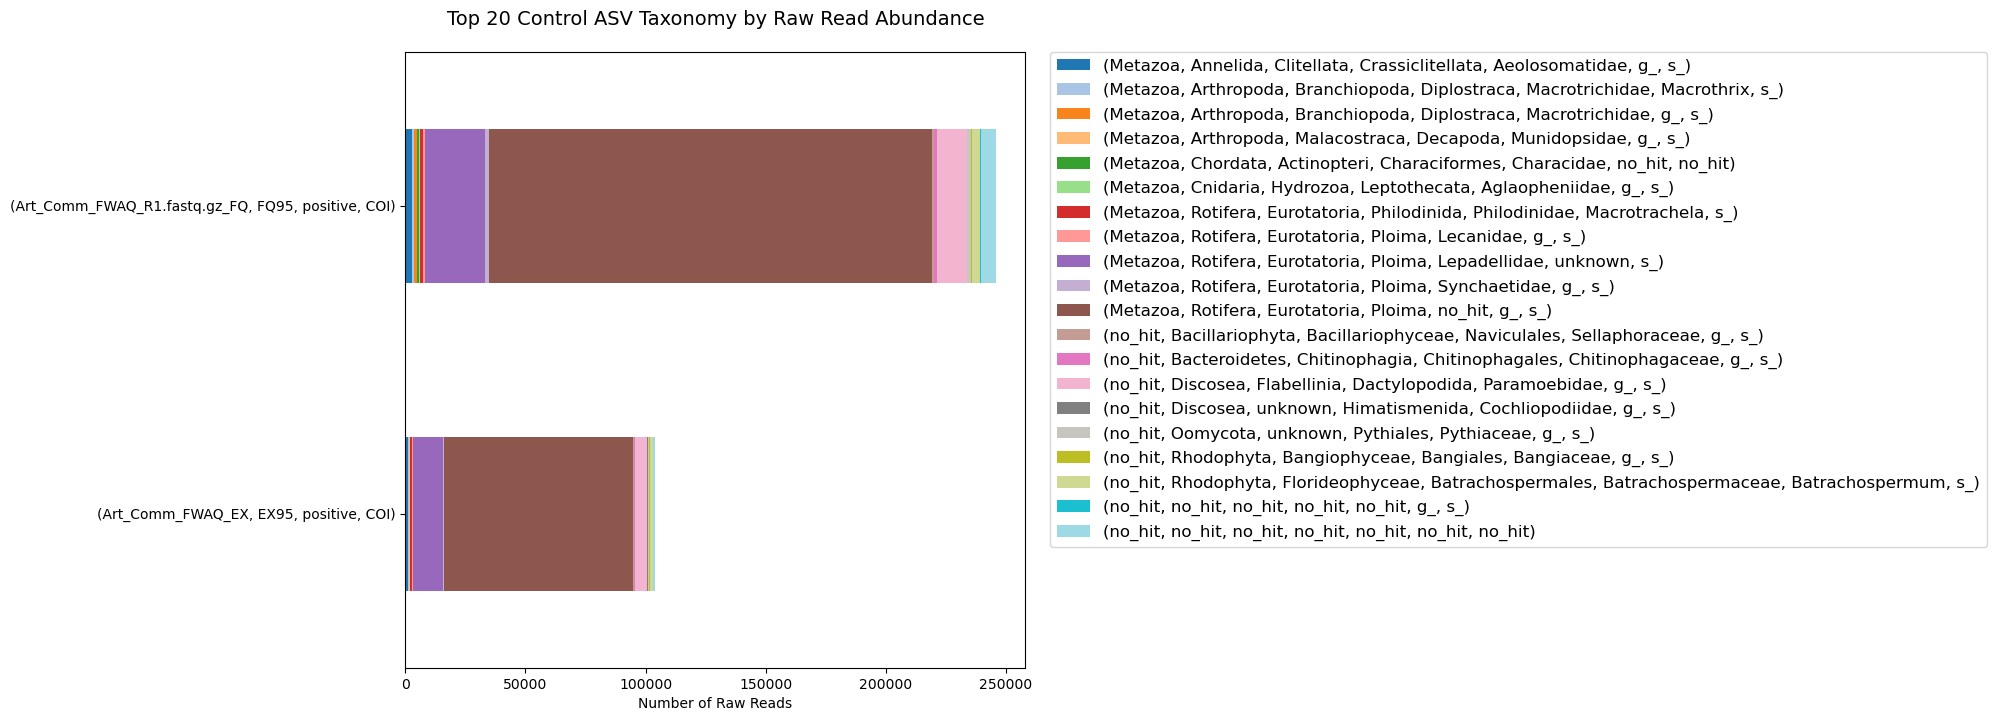

In [8]:
df = meta_all.copy()
df = df.loc[df['sample_type']!='environmental']

from palettable.tableau import Tableau_20 as pr
cmap=pr.mpl_colormap

#grouped = ['Kingdom', 'Phylum', 'Class', 'Order']
grouped= ['Kingdom', 'Phylum', 'Class', 'Order', 'Family', 'Genus', 'Species']
#df = df.loc[df['sample_type']!='environmental']
print(df['sample_type'].unique())
df = df.loc[df['sample_type']=='positive']
print(list(df))
controls = df.index.tolist()
print('controls:', controls)
df=df.sort_index()
df=df[['library','sample_type', 'target_gene']]
#Now look at reads in controls
df= pd.concat([df, otu_all.T], axis=1,join='inner')
df.index.name = 'sample_name'
df=df.reset_index().set_index(['sample_name', 'library','sample_type','target_gene'])
df=df.T
df['Tot'] = df.sum(axis=1)
df=df.loc[df['Tot']>0]
col_name = list(df)[-1]
print(col_name)
df.drop(col_name, axis=1, inplace=True)
df=pd.concat([df, taxa_all], axis=1, join='inner')
df=df.groupby(levels).sum()
df['Tot'] = df.sum(axis=1)
df=df.groupby(grouped).sum()
df=df.sort_values('Tot', ascending=False)
df=df.head(n=20)
col_name = list(df)[-1]
print(col_name)
df.drop(col_name, axis=1, inplace=True)
df = df.sort_index()
df=df.T
df = df.sort_index()
df.plot(kind='barh',stacked=True, cmap=cmap, figsize=[8,8])
plt.legend(bbox_to_anchor=(1.04, 1), loc=2, borderaxespad=0.,ncol=1, fontsize='12')
plt.title('Top 20 Control ASV Taxonomy by Raw Read Abundance', y=1.03, fontsize='14')
plt.xlabel('Number of Raw Reads')
filename=plot_dir +'PosControl_plot_'+marker+'.pdf'
print(filename)
plt.savefig(filename,dpi=None, facecolor='w', edgecolor='w',
        orientation='landscape', format=None,
        transparent=True, bbox_inches='tight', pad_inches=1)
plt.show()


### Plot Negative Controls

['negative' 'positive']
controls: ['CN24F150mMV2_preblank_R1.fastq.gz_FQ', 'CN24F150mMV2_postblank_R1.fastq.gz_FQ', 'CN_MBTS_Dual_extraction_P1_DNA_EB_R1.fastq.gz_FQ', 'CN24F150mMV2_preblank_EX', 'CN24F150mMV2_postblank_EX', 'CN_MBTS_Dual_extraction_P1_DNA_EB_EX']
('Tot', '', '', '')
Tot
../figures/NegControl_plot_COI.pdf


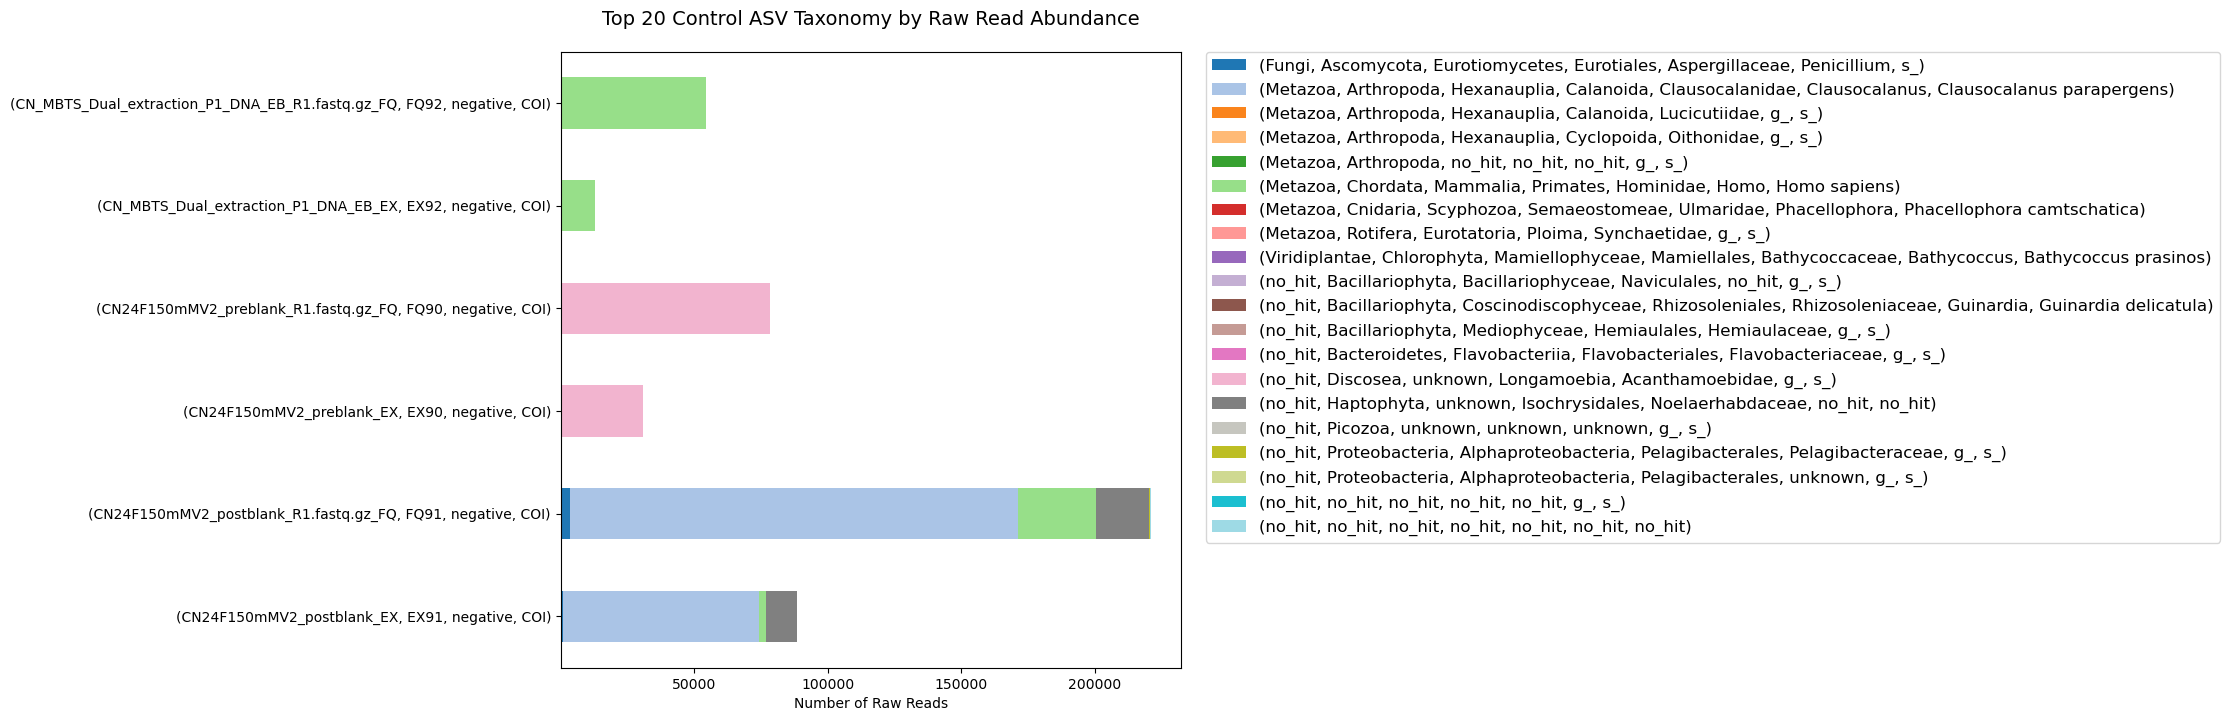

In [9]:
df = meta_all.copy()
df = df.loc[df['sample_type']!='environmental']

from palettable.tableau import Tableau_20 as pr
cmap=pr.mpl_colormap

#grouped = ['Kingdom', 'Phylum', 'Class', 'Order']
grouped= ['Kingdom', 'Phylum', 'Class', 'Order', 'Family', 'Genus', 'Species']
#df = df.loc[df['sample_type']!='environmental']
print(df['sample_type'].unique())
df = df.loc[df['sample_type']!='positive']
controls = df.index.tolist()
print('controls:', controls)
df=df.sort_index()
df=df[['library','sample_type', 'target_gene']]
#Now look at reads in controls
df= pd.concat([df, otu_all.T], axis=1,join='inner')
df.index.name = 'sample_name'
df=df.reset_index().set_index(['sample_name', 'library','sample_type','target_gene'])
df=df.T
df['Tot'] = df.sum(axis=1)
df=df.loc[df['Tot']>0]
col_name = list(df)[-1]
print(col_name)
df.drop(col_name, axis=1, inplace=True)
df=pd.concat([df, taxa_all], axis=1, join='inner')
df=df.groupby(levels).sum()
df['Tot'] = df.sum(axis=1)
df=df.groupby(grouped).sum()
df=df.sort_values('Tot', ascending=False)
df=df.head(n=20)
col_name = list(df)[-1]
print(col_name)
df.drop(col_name, axis=1, inplace=True)
df = df.sort_index()
df=df.T
df = df.sort_index()
df.plot(kind='barh',stacked=True, cmap=cmap, figsize=[8,8])
plt.legend(bbox_to_anchor=(1.04, 1), loc=2, borderaxespad=0.,ncol=1, fontsize='12')
plt.title('Top 20 Control ASV Taxonomy by Raw Read Abundance', y=1.03, fontsize='14')
plt.xlabel('Number of Raw Reads')
filename=plot_dir +'NegControl_plot_'+marker+'.pdf'
print(filename)
plt.savefig(filename,dpi=None, facecolor='w', edgecolor='w',
        orientation='landscape', format=None,
        transparent=True, bbox_inches='tight', pad_inches=1)
plt.show()


## Remove Control Samples

In [10]:
### Remove control samples
df = meta_all.copy()
df1 = df.loc[df['sample_type']!='environmental']
print('Samples removed as non-environmental:')
print(df1.index.unique())
df = df.loc[df['sample_type']=='environmental']
# df = df[['PlateID', 'sample_type', 'target_gene', 'replicate', 'eventDate', 'SAMPLING_cruise', 'SAMPLING_station_number', 'SAMPLING_bottle', 'SAMPLING_station', 'depth', 'sample_source', 'decimalLatitude', 'decimalLongitude', 'samp_filter_size_ext', 'filter_type', 'filter_style', 'seqID', 'tube_name']]


#print(df['SAMPLING_station'].unique())
#print(list(df))

meta_project = df.copy()
otu_project, taxa_project = from_metadata_to_taxareads(meta_project, otu_all, taxa_all)
meta_project.head()

Samples removed as non-environmental:
Index(['CN24F150mMV2_preblank_R1.fastq.gz_FQ',
       'CN24F150mMV2_postblank_R1.fastq.gz_FQ',
       'CN_MBTS_Dual_extraction_P1_DNA_EB_R1.fastq.gz_FQ',
       'Art_Comm_FWAQ_R1.fastq.gz_FQ', 'CN24F150mMV2_preblank_EX',
       'CN24F150mMV2_postblank_EX', 'CN_MBTS_Dual_extraction_P1_DNA_EB_EX',
       'Art_Comm_FWAQ_EX'],
      dtype='object', name='sample_name')


,ESP,PlateID,R1,R2,SAMPLING_PI,SAMPLING_bottle,SAMPLING_cruise,SAMPLING_institute,SAMPLING_platform,SAMPLING_platform_type,...,sample_type,seqID,seq_meth,sequencing_facility,tag_sequence,target_gene,temp,year,month,day
sample_name,,,,,,,,,,,,,,,,,,,,,
14223c01_05c_eDNA_R1.fastq.gz_FQ,NaN,FQ,14223c01_05c_eDNA_R1.fastq.gz,14223c01_05c_eDNA_R2.fastq.gz,Francisco Chavez,5.0,14223.0,MBARI,Rachel Carson,ship,...,environmental,14223c01_05c_eDNA_R1.fastq.gz_FQ,NGS Illumina Miseq,MSU,NaN,COI,7.8849,2023.0,5.0,22.0
14223c01_07c_eDNA_R1.fastq.gz_FQ,NaN,FQ,14223c01_07c_eDNA_R1.fastq.gz,14223c01_07c_eDNA_R2.fastq.gz,Francisco Chavez,7.0,14223.0,MBARI,Rachel Carson,ship,...,environmental,14223c01_07c_eDNA_R1.fastq.gz_FQ,NGS Illumina Miseq,MSU,NaN,COI,8.4879,2023.0,5.0,22.0
14223c01_06c_eDNA_R1.fastq.gz_FQ,NaN,FQ,14223c01_06c_eDNA_R1.fastq.gz,14223c01_06c_eDNA_R2.fastq.gz,Francisco Chavez,6.0,14223.0,MBARI,Rachel Carson,ship,...,environmental,14223c01_06c_eDNA_R1.fastq.gz_FQ,NGS Illumina Miseq,MSU,NaN,COI,8.3253,2023.0,5.0,22.0
14223c01_10c_eDNA_R1.fastq.gz_FQ,NaN,FQ,14223c01_10c_eDNA_R1.fastq.gz,14223c01_10c_eDNA_R2.fastq.gz,Francisco Chavez,10.0,14223.0,MBARI,Rachel Carson,ship,...,environmental,14223c01_10c_eDNA_R1.fastq.gz_FQ,NGS Illumina Miseq,MSU,NaN,COI,12.6401,2023.0,5.0,22.0
14223c01_04c_eDNA_R1.fastq.gz_FQ,NaN,FQ,14223c01_04c_eDNA_R1.fastq.gz,14223c01_04c_eDNA_R2.fastq.gz,Francisco Chavez,4.0,14223.0,MBARI,Rachel Carson,ship,...,environmental,14223c01_04c_eDNA_R1.fastq.gz_FQ,NGS Illumina Miseq,MSU,NaN,COI,7.3874,2023.0,5.0,22.0


## Limit by Taxonomy and ASV length

In [11]:
df= taxa_project.copy()
df=df.loc[df['Kingdom'].isin(['Bacteria', 'Archaea'])==False]
df=df.loc[df['Phylum'].isin(['Proteobacteria'])==False]
df=df.loc[df['Order'].isin(['Siluriformes', 'Centrarchiformes'])==False]
df=df.loc[df['Species'].isin(['bacterium'])==False]
#for 12S limit to
if marker == '12S':
    df = df.loc[df['Phylum']=='Chordata']
df=df.loc[df['Class'].isin(['Insecta', 'Arachnida','Amphibia'])==False]
# for consistency, replace Artiodactyla with Cetacea, if marine mammals are being mislabeled in genbank
print(df.loc[df['Order']=='Artiodactyla'])
#df['Order'] = df['Order'].str.replace('Artiodactyla', 'Cetacea')
#remove terrestrial bird and mammal families:
fams = ['Hominidae','Canidae','Scincidae','Suidae', 'Bovidae', 'Felidae',
        'Phasianidae','Castoridae','Hirundinidae','Sittidae','Columbidae',
        'Falconidae','Leporidae','Muridae','Fringillidae','Mephitidae',
        'Rhinolophidae','Certhiidae', 'Characidae', 'Callichthyidae', 'Loricariidae', 'Poeciliidae']
df = df.loc[df['Family'].isin(fams)==False]

#fix some taxonomy classifications
df.loc[df['Family'].str.contains('Embiotocidae')==True, 'Order'] = 'Ovalentaria' # surfperches 
df.loc[df['Family'].str.contains('Sciaenidae')==True, 'Order'] = 'Eupercaria' # drums 
df.loc[df['Family'].str.contains('Moronidae')==True, 'Order'] = 'Eupercaria' # temprate basses
df.loc[df['Class'].str.contains('Dinophyceae')==True, 'Phylum'] = 'Dinophyceae' # dinoflagellates 

print(df['Order'].unique())

taxa_project_nocontam = df.copy()

#check sequence length
df = pd.concat([df,seq_all ], axis=1, join='inner')
seq_project_nocontam = df[['sequence']]
df['len'] = df['sequence'].str.len()
print('Mean sequence length:',df['len'].mean())
print('Median sequence length:',df['len'].median())
print('Min sequence length:',df['len'].min())
print('Max sequence length:',df['len'].max())
print('STD:',df['len'].std())
print(df['Phylum'].unique())
print('number of ASVs: ', len(df))

#from restricted taxa table limit otu table
otu_project_nocontam = from_taxa_to_otutab(taxa_project_nocontam, otu_project)
otu_project_nocontam.head()

Empty DataFrame
Columns: [Kingdom, Phylum, Class, Order, Family, Genus, Species]
Index: []
['Isochrysidales' 'no_hit' 'unknown' 'Hemiaulales' 'Calanoida'
 'Semaeostomeae' 'Phaeocystales' 'unassigned' 'Halocyprida'
 'Poecilostomatoida' 'Parmales' 'Ploima' 'Dictyotales' 'Sphacelariales'
 'Lithodesmiales' 'Amphilepidida' 'Longamoebia' 'Thalassiosirales'
 'Cyclopoida' 'Siphonophorae' 'Leptothecata' 'Bacillariales' 'Euglyphida'
 'Prymnesiales' 'Terebellida' 'Saprolegniales' 'Rhizosoleniales'
 'Thalassionemales' 'Chromulinales' 'Fucales' 'Echiuroidea' 'Bangiales'
 'Phyllodocida' 'Chattonellales' 'Anthoathecata' 'Peronosporales'
 'Dactylopodida' 'Naviculales' 'Synurales' 'Decapoda' 'Laminariales'
 'Mamiellales' 'Suberitida' 'Eurotiales' 'Pythiales' 'Flavobacteriales'
 'Ectocarpales' 'Aphragmophora' 'Trachymedusae' 'Phlebobranchia'
 'Batrachospermales' 'Telonemida' 'Crassiclitellata' 'Stomiiformes'
 'Stylommatophora' 'Chaetocerotales' 'Pyramimonadales' 'Himatismenida'
 'Fragilariales' 'Ceramia

,14223c01_05c_eDNA_R1.fastq.gz_FQ,14223c01_07c_eDNA_R1.fastq.gz_FQ,14223c01_06c_eDNA_R1.fastq.gz_FQ,14223c01_10c_eDNA_R1.fastq.gz_FQ,14223c01_04c_eDNA_R1.fastq.gz_FQ,14223c01_09c_eDNA_R1.fastq.gz_FQ,14223c01_02c_eDNA_R1.fastq.gz_FQ,14223c01_01c_eDNA_R1.fastq.gz_FQ,14223c01_03c_eDNA_R1.fastq.gz_FQ,14223c01_12c_eDNA_R1.fastq.gz_FQ,...,CN24F150mMV2_SC50_EX,CN24F150mMV2_SC51_EX,CN24F150mMV2_SC52_EX,CN24F150mMV2_SC53_EX,CN24F150mMV2_SC54_EX,CN24F150mMV2_SC55_EX,CN24F150mMV2_SC56_EX,CN24F150mMV2_SC57_EX,CN24F150mMV2_SC58_EX,CN24F150mMV2_SC59_EX
ASV_1,4,33,4,563,4,154,1,1,0,771,...,6226,6972,7670,3020,2673,9346,5491,6420,8745,4550
ASV_2,2,164,3,46983,1410,6744,3,756,627,64534,...,1611,2123,1587,923,647,1603,2140,2085,2011,1416
ASV_3,4,17,3,905,1,16955,0,2,0,2,...,8943,252,1169,8411,5,120,9472,11649,44824,20461
ASV_4,4,24,1,1576,2,4930,232,1,2,2511,...,1222,1946,796,713,710,2153,1125,1610,1640,1086
ASV_5,6,1,3,45,3,9,3,1,1,56,...,61,57,82,27,21,72,50,70,52,41


## Fix metadata

In [12]:
df = meta_project.copy()
print(list(df))

df.loc[df['original_name'].str.contains('BSMPA')==True, 'sample_source'] = 'MPA'
df.loc[df['original_name'].str.contains('MV1')==True, 'sample_source'] = 'ESP'

df.loc[df['original_name'].str.contains('CN24F150m')==True, 'depth'] = 150
df['depth_round'] = df['depth'].astype(float).round().astype(int) 


df.loc[df['original_name'].str.contains('14223')==True, 'sample_source'] = 'CN23S MARS'
df.loc[df['original_name'].str.contains('25424')==True, 'sample_source'] = 'MBTS 25424'
df.loc[df['original_name'].str.contains('22624')==True, 'sample_source'] = 'MBTS 22624'
df.loc[df['original_name'].str.contains('20524')==True, 'sample_source'] = 'MBTS 20524'
df.loc[df['original_name'].str.contains('17024')==True, 'sample_source'] = 'MBTS 17024'
df.loc[df['original_name'].str.contains('CN24F150m')==True, 'sample_source'] = 'CN24F 150m exp'

df.loc[df['seq_meth'].str.contains('NGS')==True, 'sequencer'] = 'MiSeq'
df.loc[df['seq_meth'].str.contains('AVITI')==True, 'sequencer'] = 'AVITI'

df['source_depth'] = df['sample_source'].str.cat(df['depth_round'].astype(str), sep=' ')

# df=df.loc[df['sample_source'] =='ESP'].df.loc[df.SC.isna()]
# print(df)
# print(df.SC.unique())

print(df)
# 'SAMPLING_dec_lat', 'SAMPLING_dec_lon', 'SAMPLING_dec_long','decimalLatitude', 'decimalLongitude'
# df.loc[df['decimalLatitude'].isna()==True, 'decimalLatitude'] = df['SAMPLING_dec_lat']
# df.loc[df['decimalLongitude'].isna()==True, 'decimalLongitude'] = df['SAMPLING_dec_long']
# df.loc[df['decimalLongitude'].isna()==True, 'decimalLongitude'] = df['SAMPLING_dec_lon']
meta_project = df.copy()
df.head()

['ESP', 'PlateID', 'R1', 'R2', 'SAMPLING_PI', 'SAMPLING_bottle', 'SAMPLING_cruise', 'SAMPLING_institute', 'SAMPLING_platform', 'SAMPLING_platform_type', 'SAMPLING_rdepth', 'SAMPLING_station', 'SAMPLING_station_number', 'SC', 'chlorophyll', 'decimalLatitude', 'decimalLongitude', 'density', 'depth', 'diss_oxygen', 'env_broad_scale', 'env_local_scale', 'env_medium', 'eventDate', 'fluor', 'geo_loc_name', 'library', 'nitrate', 'order', 'original_name', 'pressure', 'primer_sequence_forward', 'primer_sequence_reverse', 'project_name', 'replicate', 'salinity', 'samp_filter_ext_type', 'samp_filter_size_ext', 'samp_store_temp', 'sample_type', 'seqID', 'seq_meth', 'sequencing_facility', 'tag_sequence', 'target_gene', 'temp', 'year', 'month', 'day']
                                  ESP PlateID  \
sample_name                                     
14223c01_05c_eDNA_R1.fastq.gz_FQ  NaN      FQ   
14223c01_07c_eDNA_R1.fastq.gz_FQ  NaN      FQ   
14223c01_06c_eDNA_R1.fastq.gz_FQ  NaN      FQ   
14223c0

,ESP,PlateID,R1,R2,SAMPLING_PI,SAMPLING_bottle,SAMPLING_cruise,SAMPLING_institute,SAMPLING_platform,SAMPLING_platform_type,...,tag_sequence,target_gene,temp,year,month,day,sample_source,depth_round,sequencer,source_depth
sample_name,,,,,,,,,,,,,,,,,,,,,
14223c01_05c_eDNA_R1.fastq.gz_FQ,NaN,FQ,14223c01_05c_eDNA_R1.fastq.gz,14223c01_05c_eDNA_R2.fastq.gz,Francisco Chavez,5.0,14223.0,MBARI,Rachel Carson,ship,...,NaN,COI,7.8849,2023.0,5.0,22.0,CN23S MARS,300,MiSeq,CN23S MARS 300
14223c01_07c_eDNA_R1.fastq.gz_FQ,NaN,FQ,14223c01_07c_eDNA_R1.fastq.gz,14223c01_07c_eDNA_R2.fastq.gz,Francisco Chavez,7.0,14223.0,MBARI,Rachel Carson,ship,...,NaN,COI,8.4879,2023.0,5.0,22.0,CN23S MARS,200,MiSeq,CN23S MARS 200
14223c01_06c_eDNA_R1.fastq.gz_FQ,NaN,FQ,14223c01_06c_eDNA_R1.fastq.gz,14223c01_06c_eDNA_R2.fastq.gz,Francisco Chavez,6.0,14223.0,MBARI,Rachel Carson,ship,...,NaN,COI,8.3253,2023.0,5.0,22.0,CN23S MARS,250,MiSeq,CN23S MARS 250
14223c01_10c_eDNA_R1.fastq.gz_FQ,NaN,FQ,14223c01_10c_eDNA_R1.fastq.gz,14223c01_10c_eDNA_R2.fastq.gz,Francisco Chavez,10.0,14223.0,MBARI,Rachel Carson,ship,...,NaN,COI,12.6401,2023.0,5.0,22.0,CN23S MARS,20,MiSeq,CN23S MARS 20
14223c01_04c_eDNA_R1.fastq.gz_FQ,NaN,FQ,14223c01_04c_eDNA_R1.fastq.gz,14223c01_04c_eDNA_R2.fastq.gz,Francisco Chavez,4.0,14223.0,MBARI,Rachel Carson,ship,...,NaN,COI,7.3874,2023.0,5.0,22.0,CN23S MARS,400,MiSeq,CN23S MARS 400


## Rename index

In [13]:
dfs = [otu_project_nocontam, taxa_project_nocontam, seq_project_nocontam]
for df in dfs:
    df.index.name = 'ASV'
df.head()

,sequence
ASV,
ASV_1,TCTAGCAGGGATTCAAGCTCATTCAGGAGGTTCTGTTGATTTAGCA...
ASV_2,TCTAGCAGGGATTCAAGCTCATTCAGGAGGTTCTGTTGATTTAGCA...
ASV_3,TTAAGAATAAATATCGCCCATTCAGGCCCATCTGTCGATTTTGCTA...
ASV_4,ATTAGCAAGTATTGCTTTCCATTCAGGAGGAGCGGTTGATTGTGCA...
ASV_5,TCTATCTGGAGGTACTGCTCATTCAGGAAGTGCTGTAGATTTAGCT...


## Save Files

In [14]:
#export to csv files for R plotting
folder = '../data/filtered_seq_data/'
dfs = [otu_project_nocontam, taxa_project_nocontam, seq_project_nocontam, meta_project]
names = ['asv', 'taxa', 'seq', 'meta']
for df, name in zip(dfs,names):
    df.to_csv(folder + prefix+ '_' +marker+'_'+name+'_filtered.csv')
    print(folder + prefix+ '_' +marker+'_'+name+'_filtered.csv')

../data/filtered_seq_data/AVITI_MiSeq_comparson_COI_asv_filtered.csv
../data/filtered_seq_data/AVITI_MiSeq_comparson_COI_taxa_filtered.csv
../data/filtered_seq_data/AVITI_MiSeq_comparson_COI_seq_filtered.csv
../data/filtered_seq_data/AVITI_MiSeq_comparson_COI_meta_filtered.csv


### Write fasta file of sequences in project:

In [15]:
df = seq_project_nocontam.copy()
outfile = folder + prefix+'_'+marker+'_seq_filtered.fasta'

seqs = df['sequence'].tolist()
otus = df.index.tolist()

##Write File
resultsFile = open(outfile, "w") #open resultsfile

for i in range(len(otus)):
    resultsFile.write('>' + otus[i])
    resultsFile.write('\n')
    resultsFile.write(seqs[i])
    resultsFile.write('\n')       
print("End")
resultsFile.close()

df.head()

End


,sequence
ASV,
ASV_1,TCTAGCAGGGATTCAAGCTCATTCAGGAGGTTCTGTTGATTTAGCA...
ASV_2,TCTAGCAGGGATTCAAGCTCATTCAGGAGGTTCTGTTGATTTAGCA...
ASV_3,TTAAGAATAAATATCGCCCATTCAGGCCCATCTGTCGATTTTGCTA...
ASV_4,ATTAGCAAGTATTGCTTTCCATTCAGGAGGAGCGGTTGATTGTGCA...
ASV_5,TCTATCTGGAGGTACTGCTCATTCAGGAAGTGCTGTAGATTTAGCT...
